# EMIPredict AI - Intelligent Financial Risk Assessment Platform

### Machine Learning Project

**Project Title:** EMIPredict AI - Intelligent Financial Risk Assessment Platform

**Submitted By:** Sakshi Nawandhar

**GitHub Repository:** https://github.com/nawandharSakshi01/EMIPredict-AI.git

---

## Problem Statement

Build a comprehensive financial risk assessment platform that integrates machine learning models with MLflow experiment tracking to create an interactive web application for EMI prediction.
Nowadays, people struggle to pay EMI due to poor financial planning and inadequate risk assessment. This project aims to solve this critical issue by providing data-driven insights for better loan decisions.
The platform should deliver:
●	Dual ML problem solving: Classification (EMI eligibility) and Regression (maximum EMI amount)
●	Real-time financial risk assessment using 400,000 records
●	Advanced feature engineering from 22 financial and demographic variables
●	ML flow integration for model tracking and comparison
●	Streamlit Cloud deployment for production-ready access
●	Complete CRUD operations for financial data management


---

## Project Objective

The objective of this project is to develop a machine learning model that predicts EMI eligibility based on customer demographic, financial, employment, credit, and loan-related information.

The model classifies customers into:

- Eligible
- High_Risk
- Not_Eligible

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook
- GitHub

---

## Project Workflow

1. Data Collection
2. Data Cleaning
3. Data Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Feature Encoding and Scaling
7. Model Training
8. Model Evaluation
9. Model Comparison
10. EMI Eligibility Prediction
11. Model Saving

---

## Dataset

**Number of Records:** 404,800  
**Number of Features:** 27

**Target Variable:** `emi_eligibility`

**Target Classes:**
- Eligible
- High_Risk
- Not_Eligible

In [64]:
import pandas as pd
import numpy as np

df = pd.read_csv("emi_prediction_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

C:\Users\Dell\AppData\Local\Temp\ipykernel_724\1918322214.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("emi_prediction_dataset.csv")


Dataset Shape: (404800, 27)

Column Names:
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure', 'emi_eligibility', 'max_monthly_emi']

Data Types:
age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
t

In [65]:
# ============================================================
# STEP 2: CHECK MISSING VALUES AND DUPLICATE RECORDS
# ============================================================

# Check the number of missing (null) values in each column.
# This helps us identify columns that need data cleaning.
print("Missing Values in Each Column:")
print(df.isnull().sum())


# Check how many completely duplicate rows are present.
# Duplicate records can affect our analysis and machine learning models.
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values in Each Column:
age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

Number of Duplicate Rows:
0


In [66]:
# ============================================================
# STEP 3: CHECK BASIC DATASET INFORMATION
# ============================================================

# Display the number of rows and columns.
print("Dataset Shape:")
print(df.shape)


# Display detailed information about the dataset.
# This includes column names, data types, and non-null counts.
print("\nDataset Information:")
df.info()

Dataset Shape:
(404800, 27)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            

In [67]:
# ============================================================
# STEP 4: CHECK CATEGORICAL / OBJECT COLUMNS
# ============================================================

# Select all columns whose data type is 'object'.
# These columns usually contain categorical or text-based data.
object_columns = df.select_dtypes(include="object").columns

print("Categorical / Object Columns:")
print(object_columns.tolist())


# Display unique values for each categorical column.
# We do this to identify inconsistent values, spelling differences,
# unexpected values, or numerical values stored as text.
for col in object_columns:
    
    print(f"\n{'=' * 60}")
    print(f"Unique Values in: {col}")
    print(f"{'=' * 60}")
    
    # Display the first 20 unique values to avoid an extremely
    # large output for columns containing many unique values.
    print(df[col].unique()[:20])

Categorical / Object Columns:
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'bank_balance', 'emi_scenario', 'emi_eligibility']

Unique Values in: age
[38.0 58.0 48.0 32.0 27.0 47.0 37.0 31.0 59.0 49.0 33.0 26.0 39.0 57.0
 28.0 '58' '38' '48' '32' '27']

Unique Values in: gender
['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']

Unique Values in: marital_status
['Married' 'Single']

Unique Values in: education
['Professional' 'Graduate' 'High School' 'Post Graduate' nan]

Unique Values in: monthly_salary
['82600.0' '21500.0' '86100.0' '66800.0' '57300.0' '38800.0' '27100.0'
 '392044.0' '47700.0' '129200.0' '58600.0' '47000.0' '11837.0' '53900.0'
 '110800.0' '64000.0' '46600.0' '77400.0' '40700.0' '47500.0']

Unique Values in: employment_type
['Private' 'Government' 'Self-employed']

Unique Values in: company_type
['Mid-size' 'MNC' 'Startup' 'Large Indian' 'Small']

Unique Values in: house_typ

In [68]:
# ============================================================
# STEP 5: CHECK NUMERICAL COLUMNS
# ============================================================

# Select columns that currently have numerical data types.
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numeric_columns.tolist())


# Generate descriptive statistics for numerical columns.
# This shows count, mean, standard deviation, minimum,
# maximum, and percentile values.
print("\nDescriptive Statistics:")
display(df[numeric_columns].describe())

Numerical Columns:


['years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']

Descriptive Statistics:


,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404800.000000,402374.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,404800.000000,402380.000000,402449.000000,4.048000e+05,404800.000000,404800.000000
mean,5.364079,5828.446490,2.940425,1.940425,4624.575593,4066.253706,5687.497777,12804.999506,7119.309783,4543.407609,700.856223,96769.051731,3.708554e+05,29.126677,6763.602156
std,6.079135,8648.604639,1.075199,1.075199,5061.074401,7319.344289,3392.671132,6993.853745,4510.447300,7034.901139,88.435548,81373.053976,3.451945e+05,18.100854,7741.263317
min,0.500000,0.000000,1.000000,0.000000,0.000000,0.000000,600.000000,1800.000000,600.000000,0.000000,0.000000,1400.000000,1.000000e+04,3.000000,500.000000
25%,1.200000,0.000000,2.000000,1.000000,0.000000,0.000000,3200.000000,7700.000000,3800.000000,0.000000,654.000000,38400.000000,1.240000e+05,15.000000,500.000000
50%,3.200000,0.000000,3.000000,2.000000,3000.000000,0.000000,4900.000000,11400.000000,6000.000000,0.000000,701.000000,74000.000000,2.360000e+05,25.000000,4211.200000
75%,7.200000,10600.000000,4.000000,3.000000,9000.000000,6500.000000,7400.000000,16400.000000,9300.000000,8000.000000,748.000000,130600.000000,4.940000e+05,40.000000,9792.000000
max,36.000000,80000.000000,5.000000,4.000000,15000.000000,25000.000000,30300.000000,71200.000000,42900.000000,56300.000000,1200.000000,891500.000000,1.500000e+06,84.000000,91040.400000


In [69]:
# ============================================================
# STEP 6: CREATE A COPY OF THE DATASET FOR CLEANING
# ============================================================

# Create a copy of the original dataset.
# We will perform all cleaning operations on df_clean.
# The original df will remain unchanged for reference.

df_clean = df.copy()

print("Clean dataset created successfully.")
print("Shape of df_clean:", df_clean.shape)

Clean dataset created successfully.
Shape of df_clean: (404800, 27)


In [70]:
# ============================================================
# STEP 7: CLEAN THE AGE COLUMN
# ============================================================

# Convert the age column to numeric format.
# Any value that cannot be converted to a number will become NaN.
df_clean["age"] = pd.to_numeric(df_clean["age"], errors="coerce")

# Display the data type after conversion.
print("Data type of age:", df_clean["age"].dtype)

# Display the first few values.
print("\nFirst 10 age values:")
print(df_clean["age"].head(10))

Data type of age: float64

First 10 age values:
0    38.0
1    38.0
2    38.0
3    58.0
4    48.0
5    38.0
6    58.0
7    58.0
8    58.0
9    32.0
Name: age, dtype: float64


In [71]:
# ============================================================
# STEP 8: CLEAN THE MONTHLY SALARY COLUMN
# ============================================================

# Convert monthly_salary into numeric format.
# Invalid/non-numeric values will be converted to NaN.
df_clean["monthly_salary"] = pd.to_numeric(
    df_clean["monthly_salary"],
    errors="coerce"
)

# Check the new data type.
print("Data type of monthly_salary:", df_clean["monthly_salary"].dtype)

# Display some sample values.
print("\nFirst 10 monthly salary values:")
print(df_clean["monthly_salary"].head(10))

Data type of monthly_salary: float64

First 10 monthly salary values:
0     82600.0
1     21500.0
2     86100.0
3     66800.0
4     57300.0
5     38800.0
6     27100.0
7    392044.0
8     47700.0
9    129200.0
Name: monthly_salary, dtype: float64


In [72]:
# ============================================================
# STEP 9: CLEAN THE BANK BALANCE COLUMN
# ============================================================

# Convert bank_balance from object/text format to numeric format.
df_clean["bank_balance"] = pd.to_numeric(
    df_clean["bank_balance"],
    errors="coerce"
)

# Check the data type after conversion.
print("Data type of bank_balance:", df_clean["bank_balance"].dtype)

# Display some sample values.
print("\nFirst 10 bank balance values:")
print(df_clean["bank_balance"].head(10))

Data type of bank_balance: float64

First 10 bank balance values:
0    303200.0
1     92500.0
2    672100.0
3    440900.0
4     97300.0
5    260800.0
6     68000.0
7    184600.0
8    235600.0
9    963200.0
Name: bank_balance, dtype: float64


In [73]:
# ============================================================
# STEP 10: STANDARDIZE THE GENDER COLUMN
# ============================================================

# Convert all gender values to lowercase and remove
# unnecessary spaces.
df_clean["gender"] = df_clean["gender"].str.strip().str.lower()

# Replace all female variations with "Female".
df_clean["gender"] = df_clean["gender"].replace({
    "female": "Female",
    "f": "Female"
})

# Replace all male variations with "Male".
df_clean["gender"] = df_clean["gender"].replace({
    "male": "Male",
    "m": "Male"
})

# Check the final unique values.
print("Unique gender values after cleaning:")
print(df_clean["gender"].unique())

Unique gender values after cleaning:
['Female' 'Male']


In [74]:
# ============================================================
# STEP 11: CHECK MISSING VALUES AFTER DATA TYPE CONVERSION
# ============================================================

# Count missing values in every column after the conversions.
missing_values = df_clean.isnull().sum()

print("Missing Values After Data Type Conversion:")
print(missing_values[missing_values > 0])

Missing Values After Data Type Conversion:
age                  3
education         2404
monthly_salary    1993
monthly_rent      2426
credit_score      2420
bank_balance      4392
emergency_fund    2351
dtype: int64


In [75]:
# ============================================================
# STEP 12: HANDLE MISSING VALUES
# ============================================================

# ------------------------------------------------------------
# 1. Handle missing values in the categorical column
# ------------------------------------------------------------

# Find the most frequently occurring education category.
education_mode = df_clean["education"].mode()[0]

# Fill missing education values with the most frequent category.
df_clean["education"] = df_clean["education"].fillna(education_mode)

print("Missing education values filled with:", education_mode)


# ------------------------------------------------------------
# 2. Handle missing values in numerical columns
# ------------------------------------------------------------

# List of numerical columns that contain missing values.
numeric_missing_columns = [
    "age",
    "monthly_salary",
    "monthly_rent",
    "credit_score",
    "bank_balance",
    "emergency_fund"
]

# Fill missing values using the median of each column.
# Median is preferred for financial data because it is less
# affected by extreme values and outliers.
for col in numeric_missing_columns:
    
    median_value = df_clean[col].median()
    
    df_clean[col] = df_clean[col].fillna(median_value)
    
    print(f"{col}: Missing values filled with median = {median_value}")

Missing education values filled with: Graduate
age: Missing values filled with median = 38.0
monthly_salary: Missing values filled with median = 51700.0
monthly_rent: Missing values filled with median = 0.0
credit_score: Missing values filled with median = 701.0
bank_balance: Missing values filled with median = 195900.0
emergency_fund: Missing values filled with median = 74000.0


In [76]:
# ============================================================
# STEP 13: VERIFY MISSING VALUES
# ============================================================

# Count missing values in every column after imputation.
missing_after_cleaning = df_clean.isnull().sum()

print("Missing Values After Imputation:")
print(missing_after_cleaning[missing_after_cleaning > 0])

# Check whether the entire dataset is free from missing values.
total_missing = df_clean.isnull().sum().sum()

print("\nTotal Missing Values in Dataset:", total_missing)

Missing Values After Imputation:
Series([], dtype: int64)

Total Missing Values in Dataset: 0


In [77]:
# ============================================================
# STEP 14: VERIFY DATA TYPES AFTER CLEANING
# ============================================================

# Display the data types of all columns after cleaning.
print("Data Types After Cleaning:")
print(df_clean.dtypes)

Data Types After Cleaning:
age                       float64
gender                     object
marital_status             object
education                  object
monthly_salary            float64
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance              float64
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object


In [78]:
# ============================================================
# STEP 15: VALIDATE CATEGORICAL VARIABLES
# ============================================================

# List of important categorical columns in the dataset.
categorical_columns = [
    "gender",
    "marital_status",
    "education",
    "employment_type",
    "company_type",
    "house_type",
    "existing_loans",
    "emi_scenario",
    "emi_eligibility"
]

# Display the unique values and their frequencies
# for each categorical column.
for col in categorical_columns:
    
    print(f"\n{'=' * 60}")
    print(f"Column: {col}")
    print(f"{'=' * 60}")
    
    print(df_clean[col].value_counts())


Column: gender
gender
Male      242950
Female    161850
Name: count, dtype: int64

Column: marital_status
marital_status
Married    307837
Single      96963
Name: count, dtype: int64

Column: education
education
Graduate         183419
Post Graduate    100314
High School       60732
Professional      60335
Name: count, dtype: int64

Column: employment_type
employment_type
Private          283099
Government        81167
Self-employed     40534
Name: count, dtype: int64

Column: company_type
company_type
Large Indian    121139
MNC             101409
Mid-size        101301
Startup          60706
Small            20245
Name: count, dtype: int64

Column: house_type
house_type
Rented    161601
Own       142307
Family    100892
Name: count, dtype: int64

Column: existing_loans
existing_loans
No     243227
Yes    161573
Name: count, dtype: int64

Column: emi_scenario
emi_scenario
Home Appliances EMI        80988
Personal Loan EMI          80980
E-commerce Shopping EMI    80948
Education EMI  

In [79]:
# ============================================================
# STEP 16: CHECK NUMERICAL VALUE RANGES
# ============================================================

# Select the main numerical columns that are important
# for financial risk analysis.
numerical_columns = [
    "age",
    "monthly_salary",
    "years_of_employment",
    "monthly_rent",
    "family_size",
    "dependents",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "max_monthly_emi"
]

# Display minimum and maximum values for each column.
range_check = pd.DataFrame({
    "Minimum": df_clean[numerical_columns].min(),
    "Maximum": df_clean[numerical_columns].max()
})

print("Minimum and Maximum Values:")
display(range_check)

Minimum and Maximum Values:


,Minimum,Maximum
age,26.0,59.0
monthly_salary,3967.0,499970.0
years_of_employment,0.5,36.0
monthly_rent,0.0,80000.0
family_size,1.0,5.0
dependents,0.0,4.0
school_fees,0.0,15000.0
college_fees,0.0,25000.0
travel_expenses,600.0,30300.0
groceries_utilities,1800.0,71200.0


In [80]:
# ============================================================
# STEP 17: CHECK FOR IMPOSSIBLE NEGATIVE VALUES
# ============================================================

# Numerical columns where negative values would not make
# practical sense in our financial dataset.
non_negative_columns = [
    "age",
    "monthly_salary",
    "years_of_employment",
    "monthly_rent",
    "family_size",
    "dependents",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "max_monthly_emi"
]

# Count negative values in each selected column.
negative_values = (df_clean[non_negative_columns] < 0).sum()

print("Negative Values in Numerical Columns:")
print(negative_values[negative_values > 0])

Negative Values in Numerical Columns:
Series([], dtype: int64)


In [81]:
# ============================================================
# STEP 18: VALIDATE CREDIT SCORE RANGE
# ============================================================

# Count credit scores below the expected minimum of 300.
credit_below_300 = (df_clean["credit_score"] < 300).sum()

# Count credit scores above the expected maximum of 850.
credit_above_850 = (df_clean["credit_score"] > 850).sum()

# Count credit scores equal to zero.
credit_equal_zero = (df_clean["credit_score"] == 0).sum()

print("Credit scores below 300:", credit_below_300)
print("Credit scores above 850:", credit_above_850)
print("Credit scores equal to 0:", credit_equal_zero)

Credit scores below 300: 1566
Credit scores above 850: 3210
Credit scores equal to 0: 1566


In [82]:
# Display some credit score values that fall outside
# the expected 300-850 range.

unusual_credit_scores = df_clean[
    (df_clean["credit_score"] < 300) |
    (df_clean["credit_score"] > 850)
]["credit_score"]

print("Unique unusual credit score values:")
print(sorted(unusual_credit_scores.unique())[:50])

Unique unusual credit score values:
[np.float64(0.0), np.float64(999.0), np.float64(1200.0)]


In [83]:
# ============================================================
# STEP 19: INVESTIGATE UNUSUAL CREDIT SCORES
# ============================================================

# Select records where credit score is outside the expected
# range of 300 to 850.
unusual_credit_data = df_clean[
    (df_clean["credit_score"] < 300) |
    (df_clean["credit_score"] > 850)
]

# Display the number of unusual records.
print("Number of unusual credit score records:",
      len(unusual_credit_data))

# Check how these unusual credit scores are distributed.
print("\nUnusual Credit Score Distribution:")
print(unusual_credit_data["credit_score"].value_counts().sort_index())

# Check EMI eligibility for these records.
print("\nEMI Eligibility Distribution:")
print(unusual_credit_data["emi_eligibility"].value_counts())

# Display average maximum EMI for each unusual credit score.
print("\nAverage Maximum EMI:")
print(
    unusual_credit_data
    .groupby("credit_score")["max_monthly_emi"]
    .mean()
)

Number of unusual credit score records: 4776

Unusual Credit Score Distribution:
credit_score
0.0       1566
999.0     1582
1200.0    1628
Name: count, dtype: int64

EMI Eligibility Distribution:
emi_eligibility
Not_Eligible    3687
Eligible         889
High_Risk        200
Name: count, dtype: int64

Average Maximum EMI:
credit_score
0.0       6818.512765
999.0     6976.347073
1200.0    6935.883139
Name: max_monthly_emi, dtype: float64


In [84]:
# ============================================================
# STEP 21: CLEAN INVALID CREDIT SCORES
# ============================================================

# The project specifies a valid credit score range of 300 to 850.
# Therefore, values outside this range are treated as invalid.

# Replace invalid credit scores with NaN.
df_clean.loc[
    (df_clean["credit_score"] < 300) |
    (df_clean["credit_score"] > 850),
    "credit_score"
] = np.nan

# Count the newly identified missing credit scores.
print("Invalid credit scores converted to missing values:",
      df_clean["credit_score"].isnull().sum())

Invalid credit scores converted to missing values: 4776


In [85]:
# ============================================================
# STEP 22: IMPUTE INVALID CREDIT SCORES
# ============================================================

# Calculate the median using only valid credit scores
# that fall within the 300-850 range.
credit_score_median = df_clean["credit_score"].median()

print("Median of valid credit scores:", credit_score_median)

# Fill the invalid/missing credit scores with the median.
df_clean["credit_score"] = df_clean["credit_score"].fillna(
    credit_score_median
)

print("\nMissing credit scores after imputation:",
      df_clean["credit_score"].isnull().sum())

Median of valid credit scores: 701.0

Missing credit scores after imputation: 0


In [86]:
# ============================================================
# STEP 23: VERIFY CREDIT SCORE AFTER CLEANING
# ============================================================

print("Minimum Credit Score:",
      df_clean["credit_score"].min())

print("Maximum Credit Score:",
      df_clean["credit_score"].max())

print("\nMissing Credit Scores:",
      df_clean["credit_score"].isnull().sum())

Minimum Credit Score: 407.0
Maximum Credit Score: 850.0

Missing Credit Scores: 0


In [87]:
# ============================================================
# STEP 24: FINAL DATA QUALITY CHECK
# ============================================================

# Check the final shape of the cleaned dataset.
print("Cleaned Dataset Shape:")
print(df_clean.shape)


# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------

print("\nTotal Missing Values:")
print(df_clean.isnull().sum().sum())


# ------------------------------------------------------------
# Check for duplicate records
# ------------------------------------------------------------

print("\nTotal Duplicate Rows:")
print(df_clean.duplicated().sum())


# ------------------------------------------------------------
# Check data types
# ------------------------------------------------------------

print("\nFinal Data Types:")
print(df_clean.dtypes)


# ------------------------------------------------------------
# Display the first five rows
# ------------------------------------------------------------

print("\nFirst Five Rows of Cleaned Dataset:")
display(df_clean.head())

Cleaned Dataset Shape:
(404800, 27)

Total Missing Values:
0

Total Duplicate Rows:
0

Final Data Types:
age                       float64
gender                     object
marital_status             object
education                  object
monthly_salary            float64
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance              float64
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [88]:
# ============================================================
# STEP 25: SAVE THE CLEANED DATASET
# ============================================================

# Save the cleaned dataframe as a new CSV file.
# We keep the original dataset unchanged and create a
# separate cleaned version for further analysis and modeling.

df_clean.to_csv("emi_prediction_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("File name: emi_prediction_cleaned.csv")

Cleaned dataset saved successfully!
File name: emi_prediction_cleaned.csv


In [89]:
# ============================================================
# STEP 26: IMPORT LIBRARIES FOR EXPLORATORY DATA ANALYSIS
# ============================================================

# Pandas is used for data manipulation and analysis.
import pandas as pd

# NumPy is used for numerical calculations.
import numpy as np

# Matplotlib is used for creating basic visualizations.
import matplotlib.pyplot as plt

# Seaborn is used for statistical visualizations.
import seaborn as sns

# Display plots directly inside the Jupyter Notebook.
%matplotlib inline

print("EDA libraries imported successfully!")

EDA libraries imported successfully!


In [90]:
# ============================================================
# STEP 27: EMI ELIGIBILITY DISTRIBUTION
# ============================================================

# Count the number of customers in each EMI eligibility category.
eligibility_counts = df_clean["emi_eligibility"].value_counts()

print("EMI Eligibility Counts:")
print(eligibility_counts)


# Calculate the percentage of each eligibility category.
eligibility_percentage = (
    df_clean["emi_eligibility"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nEMI Eligibility Percentage:")
print(eligibility_percentage)

EMI Eligibility Counts:
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

EMI Eligibility Percentage:
emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64


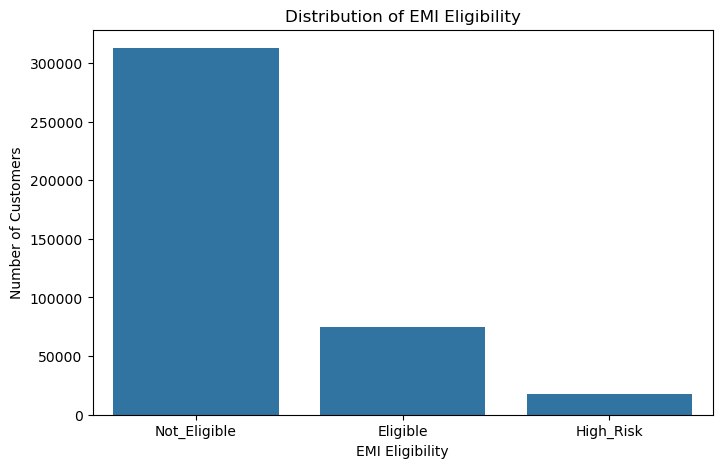

In [91]:
# ============================================================
# STEP 28: VISUALIZE EMI ELIGIBILITY DISTRIBUTION
# ============================================================

# Create a figure for the chart.
plt.figure(figsize=(8, 5))

# Create a count plot showing the number of customers
# in each EMI eligibility category.
sns.countplot(
    data=df_clean,
    x="emi_eligibility",
    order=df_clean["emi_eligibility"].value_counts().index
)

# Add a title to the chart.
plt.title("Distribution of EMI Eligibility")

# Label the x-axis.
plt.xlabel("EMI Eligibility")

# Label the y-axis.
plt.ylabel("Number of Customers")

# Display the chart.
plt.show()

In [92]:
# ============================================================
# STEP 29: ANALYZE MAXIMUM MONTHLY EMI
# ============================================================

# Display descriptive statistics for maximum monthly EMI.
print("Descriptive Statistics for Maximum Monthly EMI:")
print(df_clean["max_monthly_emi"].describe())

Descriptive Statistics for Maximum Monthly EMI:
count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64


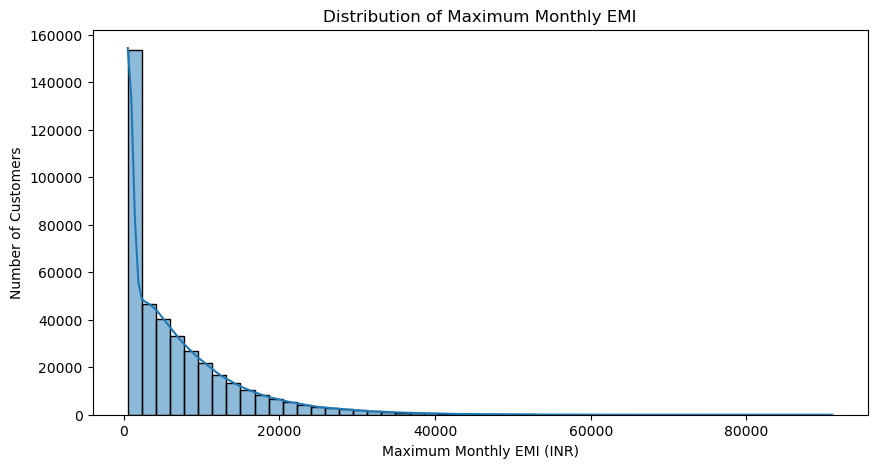

In [93]:
# ============================================================
# STEP 30: DISTRIBUTION OF MAXIMUM MONTHLY EMI
# ============================================================

# Create a figure for the distribution plot.
plt.figure(figsize=(10, 5))

# Plot the distribution of maximum monthly EMI.
sns.histplot(
    data=df_clean,
    x="max_monthly_emi",
    bins=50,
    kde=True
)

# Add chart title.
plt.title("Distribution of Maximum Monthly EMI")

# Label the x-axis.
plt.xlabel("Maximum Monthly EMI (INR)")

# Label the y-axis.
plt.ylabel("Number of Customers")

# Display the chart.
plt.show()

#Maximum Monthly EMI shows a highly right-skewed distribution. Most customers have relatively 
# low maximum monthly EMI values, while a smaller number of customers have substantially higher 
# EMI capacities. This indicates significant variation in customers' repayment capacity.

Age Statistics:
count    404800.000000
mean         38.875825
std           9.303538
min          26.000000
25%          32.000000
50%          38.000000
75%          48.000000
max          59.000000
Name: age, dtype: float64


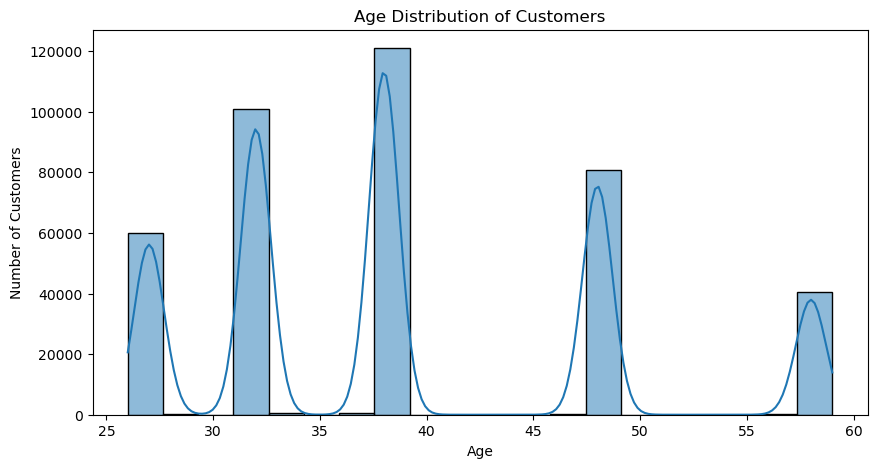

In [94]:
# ============================================================
# STEP 31: AGE DISTRIBUTION
# ============================================================

# Display descriptive statistics for age.
print("Age Statistics:")
print(df_clean["age"].describe())

# Create the age distribution plot.
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=20,
    kde=True
)

# Add title and axis labels.
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

# Display the plot.
plt.show()

Age Distribution: The customers have an average age of approximately 38.9 years, with ages ranging from 26 to 59 years. The distribution shows distinct concentrations around several age groups, indicating that customers are not evenly distributed across the age range.

Gender Distribution:
gender
Male      242950
Female    161850
Name: count, dtype: int64

Gender Percentage:
gender
Male      60.02
Female    39.98
Name: proportion, dtype: float64


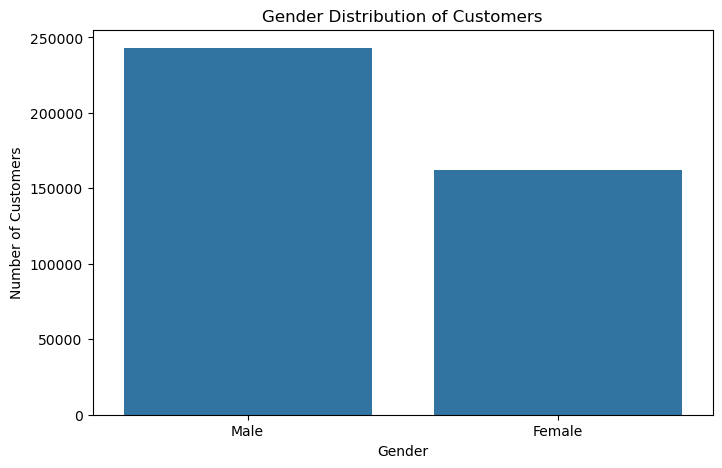

In [95]:
# ============================================================
# STEP 32: GENDER DISTRIBUTION
# ============================================================

# Count customers in each gender category.
gender_counts = df_clean["gender"].value_counts()

print("Gender Distribution:")
print(gender_counts)

# Calculate percentage distribution.
gender_percentage = (
    df_clean["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nGender Percentage:")
print(gender_percentage)


# ------------------------------------------------------------
# Create the visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="gender",
    order=df_clean["gender"].value_counts().index
)

plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

Education Distribution:
education
Graduate         183419
Post Graduate    100314
High School       60732
Professional      60335
Name: count, dtype: int64

Education Percentage:
education
Graduate         45.31
Post Graduate    24.78
High School      15.00
Professional     14.90
Name: proportion, dtype: float64


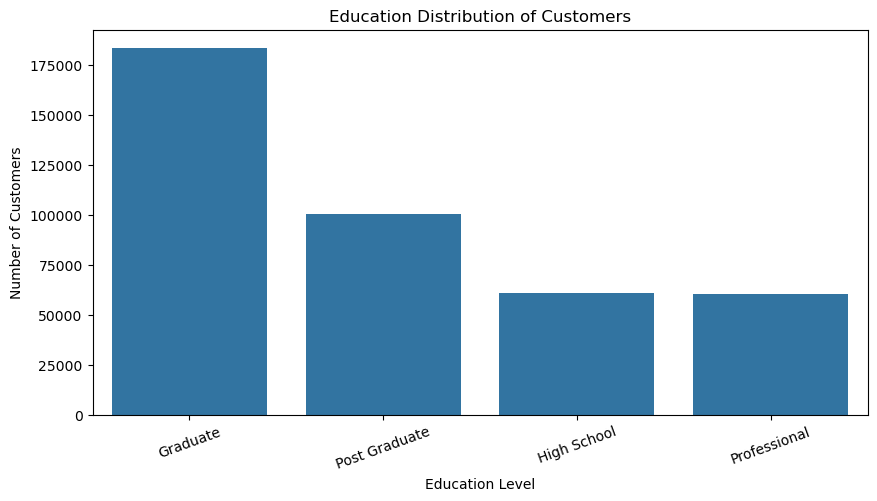

In [96]:
# ============================================================
# STEP 33: EDUCATION DISTRIBUTION
# ============================================================

# Count customers in each education category.
education_counts = df_clean["education"].value_counts()

print("Education Distribution:")
print(education_counts)


# Calculate percentage distribution.
education_percentage = (
    df_clean["education"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nEducation Percentage:")
print(education_percentage)


# ------------------------------------------------------------
# Create the visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_clean,
    x="education",
    order=df_clean["education"].value_counts().index
)

plt.title("Education Distribution of Customers")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")

# Rotate labels slightly if needed.
plt.xticks(rotation=20)

plt.show()

Education Distribution: Graduate customers form the largest group, representing 45.31% of the dataset, followed by Post Graduate customers at 24.78%. High School and Professional customers each account for approximately 15% of the dataset.

Marital Status Distribution:
marital_status
Married    307837
Single      96963
Name: count, dtype: int64

Marital Status Percentage:
marital_status
Married    76.05
Single     23.95
Name: proportion, dtype: float64


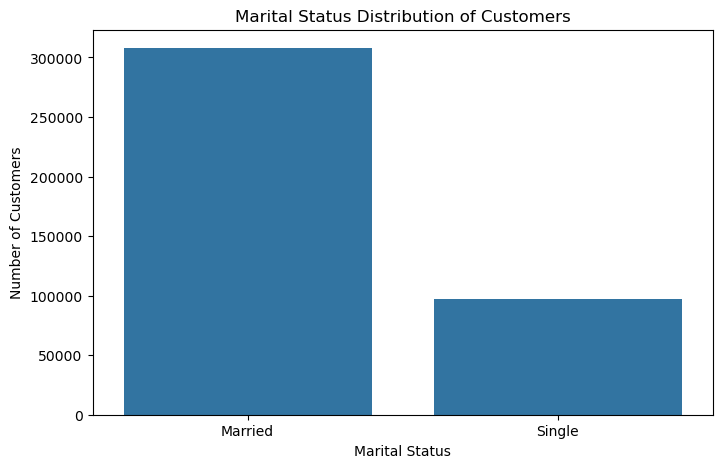

In [97]:
# ============================================================
# STEP 34: MARITAL STATUS DISTRIBUTION
# ============================================================

# Count customers in each marital status category.
marital_counts = df_clean["marital_status"].value_counts()

print("Marital Status Distribution:")
print(marital_counts)


# Calculate percentage distribution.
marital_percentage = (
    df_clean["marital_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nMarital Status Percentage:")
print(marital_percentage)


# ------------------------------------------------------------
# Create the visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="marital_status",
    order=df_clean["marital_status"].value_counts().index
)

plt.title("Marital Status Distribution of Customers")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

plt.show()

Marital Status Distribution: Married customers represent the majority of the dataset, accounting for 76.05% of customers, while single customers account for 23.95%.

Gender vs EMI Eligibility (%):
emi_eligibility  Eligible  High_Risk  Not_Eligible
gender                                            
Female              18.39       4.32         77.29
Male                18.39       4.32         77.29


<Figure size 900x500 with 0 Axes>

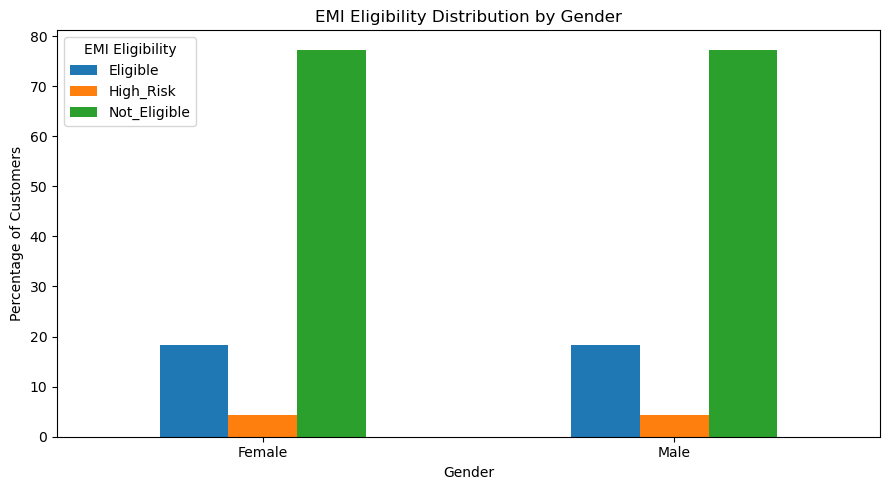

In [98]:
# ============================================================
# STEP 35: GENDER VS EMI ELIGIBILITY
# ============================================================

# Create a cross-tabulation showing the percentage of each
# EMI eligibility category within each gender.
gender_eligibility = pd.crosstab(
    df_clean["gender"],
    df_clean["emi_eligibility"],
    normalize="index"
) * 100

# Round percentages to two decimal places.
gender_eligibility = gender_eligibility.round(2)

print("Gender vs EMI Eligibility (%):")
print(gender_eligibility)


# ------------------------------------------------------------
# Create the visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

gender_eligibility.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("EMI Eligibility Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Customers")

# Rotate x-axis labels for readability.
plt.xticks(rotation=0)

# Add legend.
plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

Gender vs EMI Eligibility: EMI eligibility is distributed identically across male and female customers in this dataset. Both groups have 18.39% Eligible, 4.32% High Risk, and 77.29% Not Eligible customers. Therefore, based on this descriptive analysis, gender does not appear to differentiate EMI eligibility.

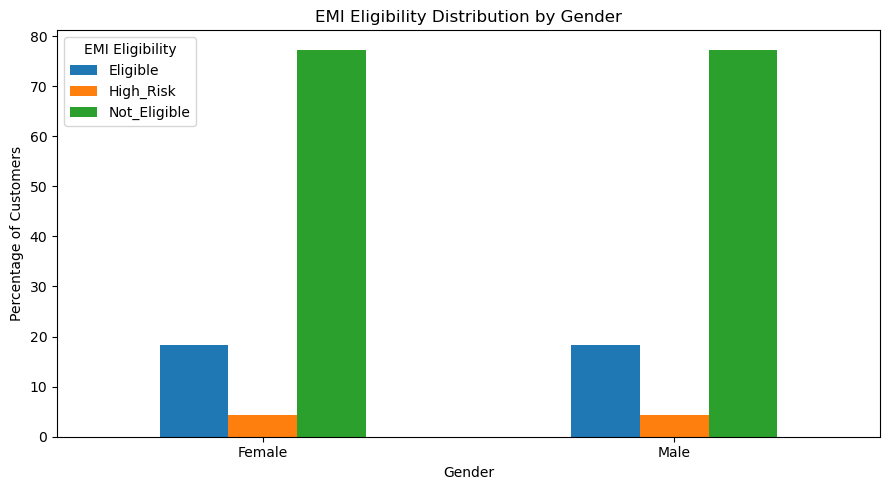

In [99]:
# ============================================================
# IMPROVED GENDER VS EMI ELIGIBILITY VISUALIZATION
# ============================================================

ax = gender_eligibility.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("EMI Eligibility Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)
plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

Education vs EMI Eligibility (%):
emi_eligibility  Eligible  High_Risk  Not_Eligible
education                                         
Graduate            15.72       4.04         80.23
High School         11.11       3.24         85.65
Post Graduate       22.45       4.91         72.64
Professional        27.08       5.27         67.65


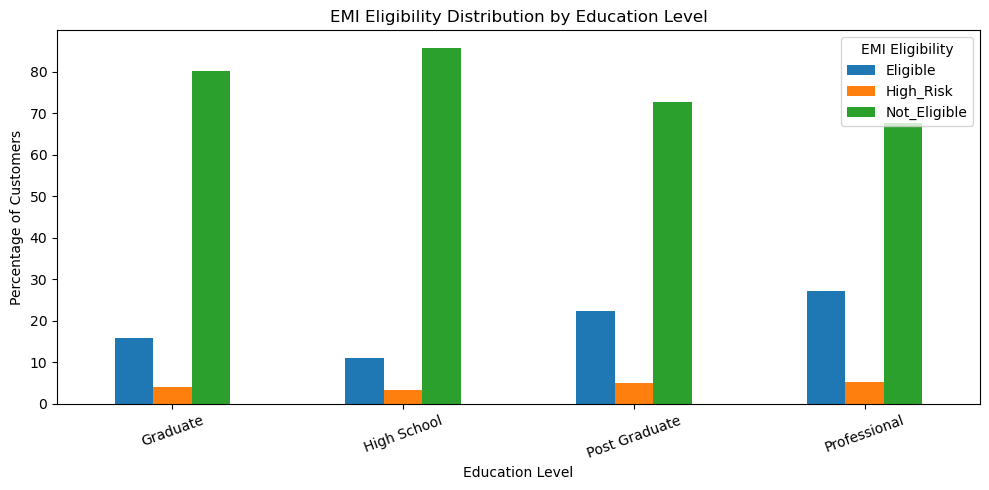

In [100]:
# ============================================================
# STEP 36: EDUCATION VS EMI ELIGIBILITY
# ============================================================

# Calculate the percentage of each EMI eligibility category
# within every education group.
education_eligibility = pd.crosstab(
    df_clean["education"],
    df_clean["emi_eligibility"],
    normalize="index"
) * 100

# Round percentages to two decimal places.
education_eligibility = education_eligibility.round(2)

print("Education vs EMI Eligibility (%):")
print(education_eligibility)


# ------------------------------------------------------------
# Create the visualization
# ------------------------------------------------------------

ax = education_eligibility.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("EMI Eligibility Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=20)

plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

Education vs EMI Eligibility: EMI eligibility varies noticeably across education levels. Professional customers have the highest eligible proportion (27.08%), while High School customers have the lowest (11.11%). High School customers also have the highest proportion of Not_Eligible cases (85.65%). This suggests that education level may be associated with EMI eligibility in the dataset.

Age Group vs EMI Eligibility (%):
emi_eligibility  Eligible  High_Risk  Not_Eligible
age_group                                         
26-30               18.91       4.42         76.67
31-35               18.24       4.32         77.45
36-40               18.25       4.22         77.53
46-50               18.41       4.36         77.23
56-60               18.37       4.39         77.23


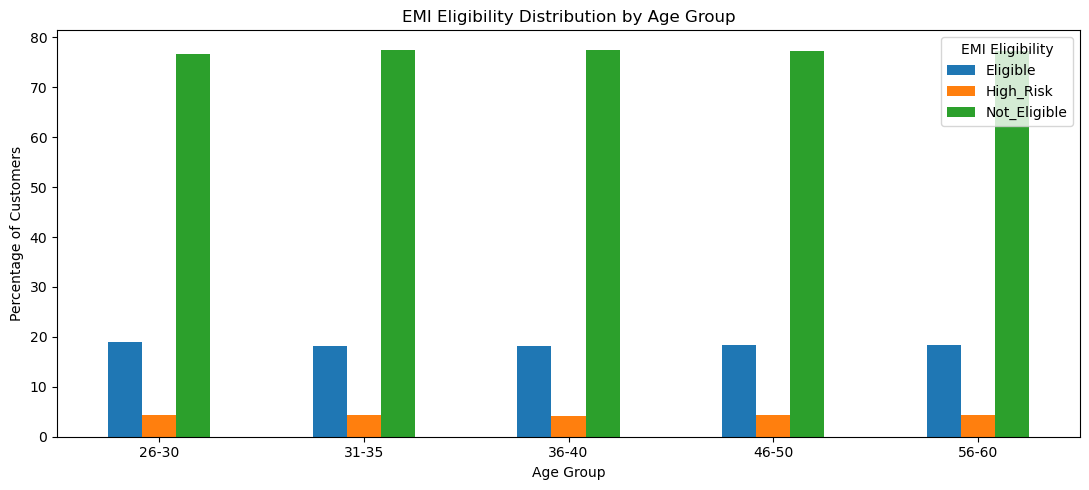

In [101]:
# ============================================================
# STEP 37: AGE GROUP VS EMI ELIGIBILITY
# ============================================================

# Create age groups to make the analysis easier to interpret.
age_bins = [25, 30, 35, 40, 45, 50, 55, 60]

age_labels = [
    "26-30",
    "31-35",
    "36-40",
    "41-45",
    "46-50",
    "51-55",
    "56-60"
]

# Create a new column containing the age group.
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)


# ------------------------------------------------------------
# Calculate EMI eligibility percentage within each age group
# ------------------------------------------------------------

age_eligibility = pd.crosstab(
    df_clean["age_group"],
    df_clean["emi_eligibility"],
    normalize="index"
) * 100

# Round percentages to two decimal places.
age_eligibility = age_eligibility.round(2)

print("Age Group vs EMI Eligibility (%):")
print(age_eligibility)


# ------------------------------------------------------------
# Create the visualization
# ------------------------------------------------------------

ax = age_eligibility.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("EMI Eligibility Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)

plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

Age Group vs EMI Eligibility: EMI eligibility percentages are very similar across the observed age groups. The Eligible proportion ranges from 18.24% to 18.91%, while Not_Eligible ranges from 76.67% to 77.53%. Therefore, age group does not show a strong descriptive difference in EMI eligibility in this dataset.

In [102]:
# Remove the temporary age group column used only for EDA.
df_clean.drop(columns=["age_group"], inplace=True)

Employment Type vs EMI Eligibility (%):
emi_eligibility  Eligible  High_Risk  Not_Eligible
employment_type                                   
Government          21.40       4.61         73.99
Private             17.80       4.27         77.94
Self-employed       16.52       4.09         79.39


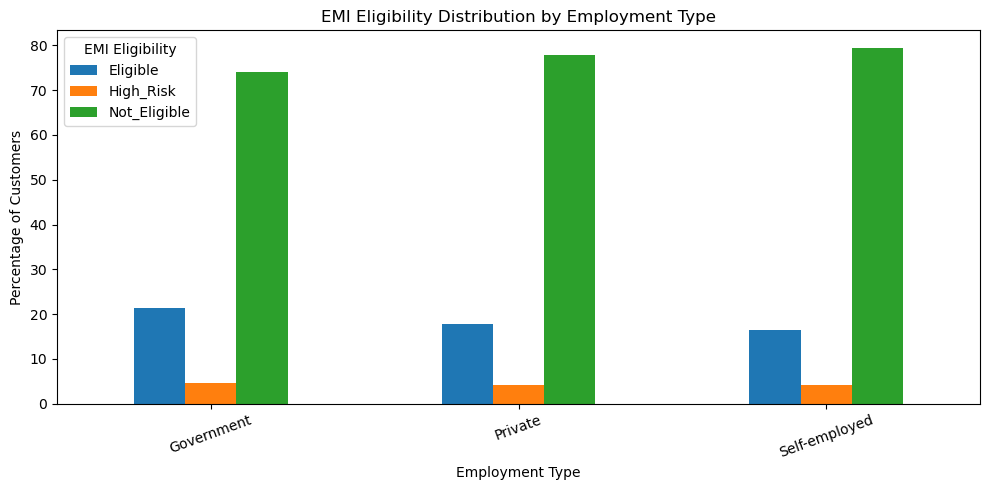

In [103]:
# ============================================================
# STEP 38: EMPLOYMENT TYPE VS EMI ELIGIBILITY
# ============================================================

# Calculate EMI eligibility percentages within each
# employment type.
employment_eligibility = pd.crosstab(
    df_clean["employment_type"],
    df_clean["emi_eligibility"],
    normalize="index"
) * 100

# Round the percentages.
employment_eligibility = employment_eligibility.round(2)

print("Employment Type vs EMI Eligibility (%):")
print(employment_eligibility)


# ------------------------------------------------------------
# Create the visualization
# ------------------------------------------------------------

ax = employment_eligibility.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("EMI Eligibility Distribution by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=20)

plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

Employment Type vs EMI Eligibility: Government employees have the highest Eligible proportion at 21.40%, while self-employed customers have the lowest at 16.52%. Self-employed customers also have the highest Not_Eligible proportion at 79.39%. This indicates that EMI eligibility varies across employment types in the dataset.

Monthly Salary Statistics:
count    404800.000000
mean      59470.891843
std       43284.807915
min        3967.000000
25%       35400.000000
50%       51700.000000
75%       72800.000000
max      499970.000000
Name: monthly_salary, dtype: float64


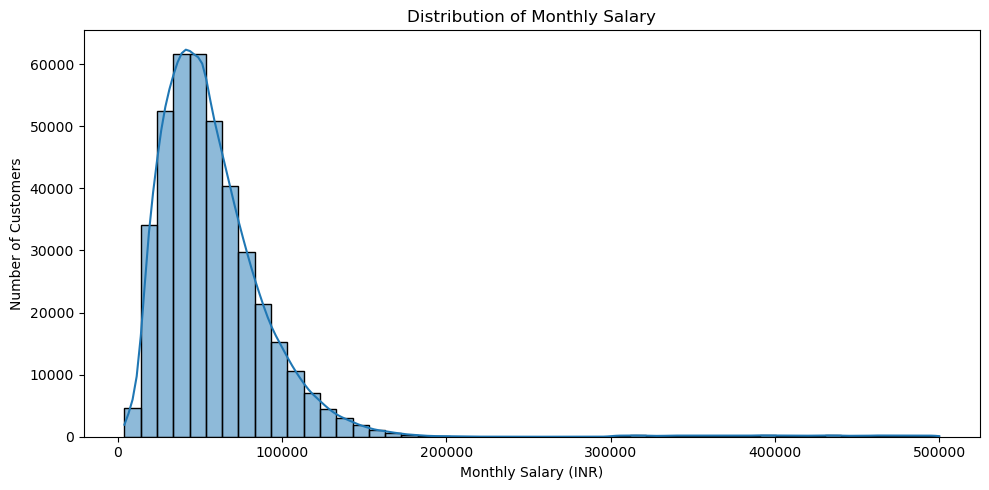

In [104]:
# ============================================================
# STEP 39: MONTHLY SALARY DISTRIBUTION
# ============================================================

# Display descriptive statistics for monthly salary.
print("Monthly Salary Statistics:")
print(df_clean["monthly_salary"].describe())


# ------------------------------------------------------------
# Create the distribution plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="monthly_salary",
    bins=50,
    kde=True
)

plt.title("Distribution of Monthly Salary")
plt.xlabel("Monthly Salary (INR)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Monthly Salary Distribution: Monthly salaries range from ₹3,967 to ₹4,99,970, with a median salary of ₹51,700. The distribution is positively skewed, with most customers concentrated in the lower-to-middle salary range and a smaller number of customers having substantially higher salaries.

Monthly Salary by EMI Eligibility:
                  count      mean   median     min       max
emi_eligibility                                             
Eligible          74444  78860.94  72600.0  4551.0  499761.0
High_Risk         17488  70197.67  63600.0  5028.0  495779.0
Not_Eligible     312868  54257.63  47100.0  3967.0  499970.0


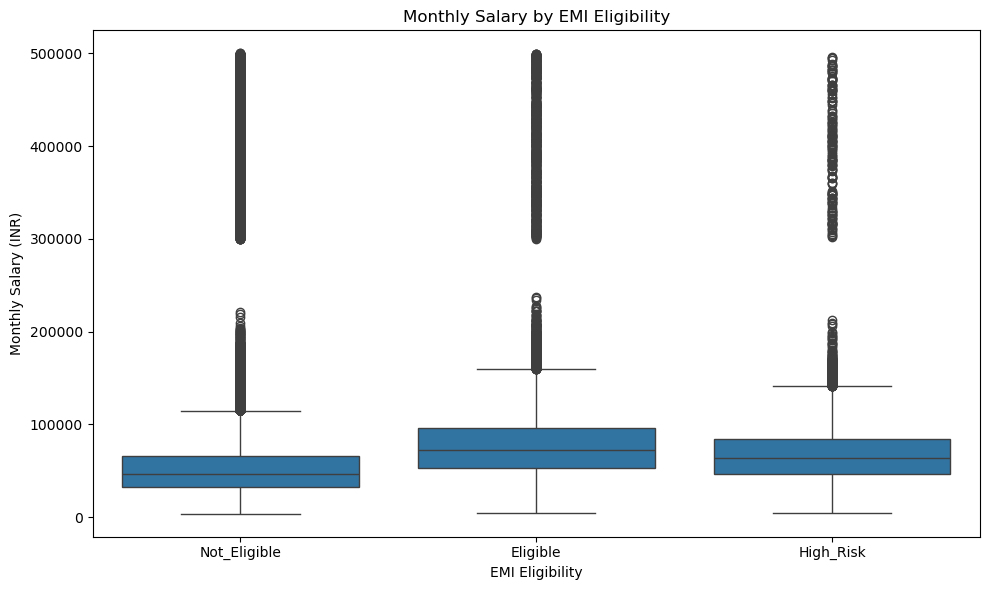

In [105]:
# ============================================================
# STEP 40: MONTHLY SALARY VS EMI ELIGIBILITY
# ============================================================

# Display median salary for each EMI eligibility category.
salary_by_eligibility = (
    df_clean
    .groupby("emi_eligibility")["monthly_salary"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Monthly Salary by EMI Eligibility:")
print(salary_by_eligibility)


# ------------------------------------------------------------
# Create the box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="monthly_salary"
)

plt.title("Monthly Salary by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Monthly Salary (INR)")

plt.tight_layout()
plt.show()

Monthly Salary vs EMI Eligibility: Eligible customers have the highest average monthly salary (₹78,860.94), followed by High Risk customers (₹70,197.67), while Not_Eligible customers have the lowest average salary (₹54,257.63). The same pattern is observed in the median salary. This suggests a strong positive relationship between monthly salary and EMI eligibility in the dataset.

Existing Loans vs EMI Eligibility (%):
emi_eligibility  Eligible  High_Risk  Not_Eligible
existing_loans                                    
No                  25.78       5.61         68.61
Yes                  7.27       2.38         90.35


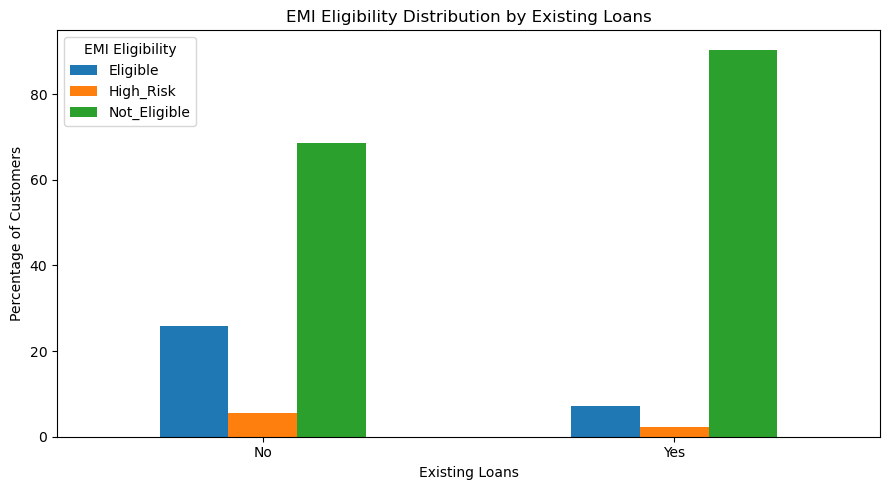

In [106]:
# ============================================================
# STEP 41: EXISTING LOANS VS EMI ELIGIBILITY
# ============================================================

# Calculate EMI eligibility percentages within each
# existing-loans category.
loans_eligibility = pd.crosstab(
    df_clean["existing_loans"],
    df_clean["emi_eligibility"],
    normalize="index"
) * 100

# Round percentages to two decimal places.
loans_eligibility = loans_eligibility.round(2)

print("Existing Loans vs EMI Eligibility (%):")
print(loans_eligibility)


# ------------------------------------------------------------
# Create the visualization
# ------------------------------------------------------------

ax = loans_eligibility.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("EMI Eligibility Distribution by Existing Loans")
plt.xlabel("Existing Loans")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=0)

plt.legend(title="EMI Eligibility")

plt.tight_layout()
plt.show()

Existing Loans vs EMI Eligibility: Customers without existing loans have a substantially higher Eligible proportion (25.78%) compared with customers who already have loans (7.27%). Customers with existing loans also have a much higher Not_Eligible proportion (90.35%) compared with those without existing loans (68.61%). This indicates that existing loan obligations are strongly associated with EMI eligibility in the dataset.

Current EMI Amount by EMI Eligibility:
                  count     mean  median  min      max
emi_eligibility                                       
Eligible          74444  2405.85     0.0  0.0  54300.0
High_Risk         17488  3088.11     0.0  0.0  50900.0
Not_Eligible     312868  5133.36     0.0  0.0  56300.0


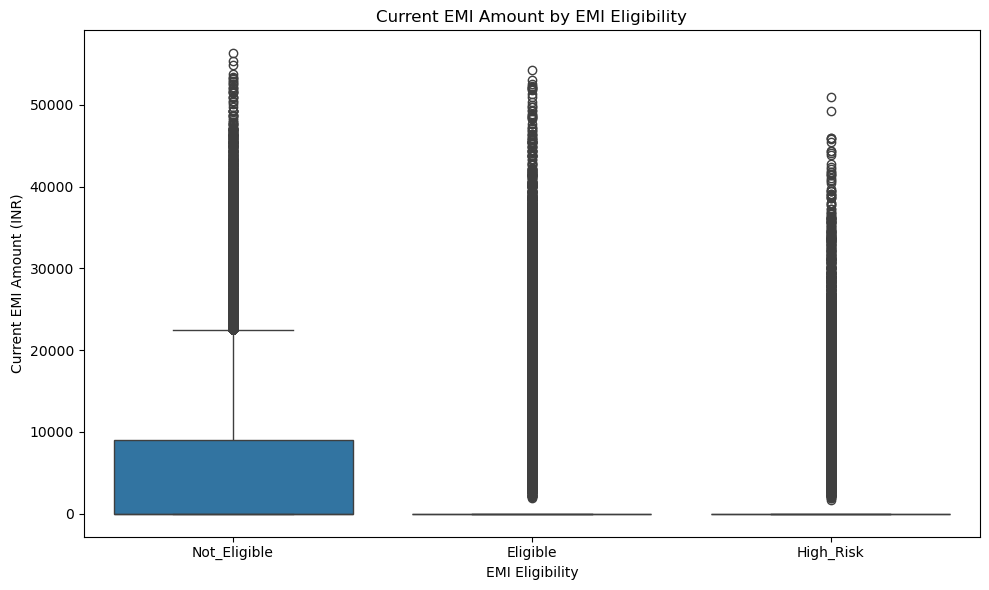

In [107]:
# ============================================================
# STEP 42: CURRENT EMI AMOUNT VS EMI ELIGIBILITY
# ============================================================

# Calculate summary statistics for current EMI amount
# within each EMI eligibility category.
current_emi_summary = (
    df_clean
    .groupby("emi_eligibility")["current_emi_amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Current EMI Amount by EMI Eligibility:")
print(current_emi_summary)


# ------------------------------------------------------------
# Create the box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="current_emi_amount"
)

plt.title("Current EMI Amount by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Current EMI Amount (INR)")

plt.tight_layout()
plt.show()

Current EMI Amount vs EMI Eligibility: Not_Eligible customers have the highest average current EMI amount at ₹5,133.36, compared with ₹3,088.11 for High_Risk customers and ₹2,405.85 for Eligible customers. This suggests that a higher existing EMI burden is associated with lower EMI eligibility in the dataset.

Total Monthly Expenses Statistics:
count    404800.000000
mean      40096.152490
std       20307.683573
min        3400.000000
25%       25300.000000
50%       36700.000000
75%       51100.000000
max      207500.000000
Name: total_monthly_expenses, dtype: float64

Total Monthly Expenses by EMI Eligibility:
                  count      mean   median     min       max
emi_eligibility                                             
Eligible          74444  42497.18  39100.0  4300.0  207500.0
High_Risk         17488  39640.74  36100.0  4100.0  160800.0
Not_Eligible     312868  39550.31  36200.0  3400.0  195300.0


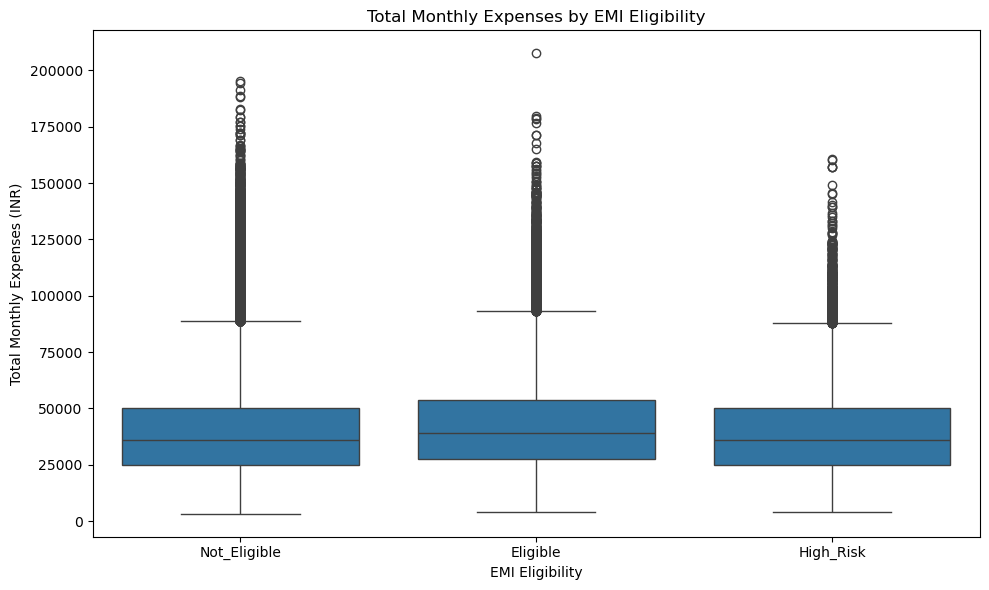

In [108]:
# ============================================================
# STEP 43: TOTAL MONTHLY EXPENSES
# ============================================================

# Calculate the customer's total monthly expenses by adding
# all major monthly expense components.
df_clean["total_monthly_expenses"] = (
    df_clean["monthly_rent"]
    + df_clean["school_fees"]
    + df_clean["college_fees"]
    + df_clean["travel_expenses"]
    + df_clean["groceries_utilities"]
    + df_clean["other_monthly_expenses"]
)

# Display summary statistics.
print("Total Monthly Expenses Statistics:")
print(df_clean["total_monthly_expenses"].describe())


# ------------------------------------------------------------
# Compare total expenses across EMI eligibility categories
# ------------------------------------------------------------

expense_summary = (
    df_clean
    .groupby("emi_eligibility")["total_monthly_expenses"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\nTotal Monthly Expenses by EMI Eligibility:")
print(expense_summary)


# ------------------------------------------------------------
# Create the box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="total_monthly_expenses"
)

plt.title("Total Monthly Expenses by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Total Monthly Expenses (INR)")

plt.tight_layout()
plt.show()

Total Monthly Expenses vs EMI Eligibility: Eligible customers have the highest average monthly expenses (₹42,497.18), while High_Risk and Not_Eligible customers have similar average expenses of approximately ₹39,641 and ₹39,550 respectively. Therefore, total monthly expenses alone do not show a simple negative relationship with EMI eligibility in this dataset.

Credit Score by EMI Eligibility:
                  count    mean  median    min    max
emi_eligibility                                      
Eligible          74444  725.17   725.0  432.0  850.0
High_Risk         17488  715.69   714.0  482.0  850.0
Not_Eligible     312868  693.65   695.0  407.0  850.0


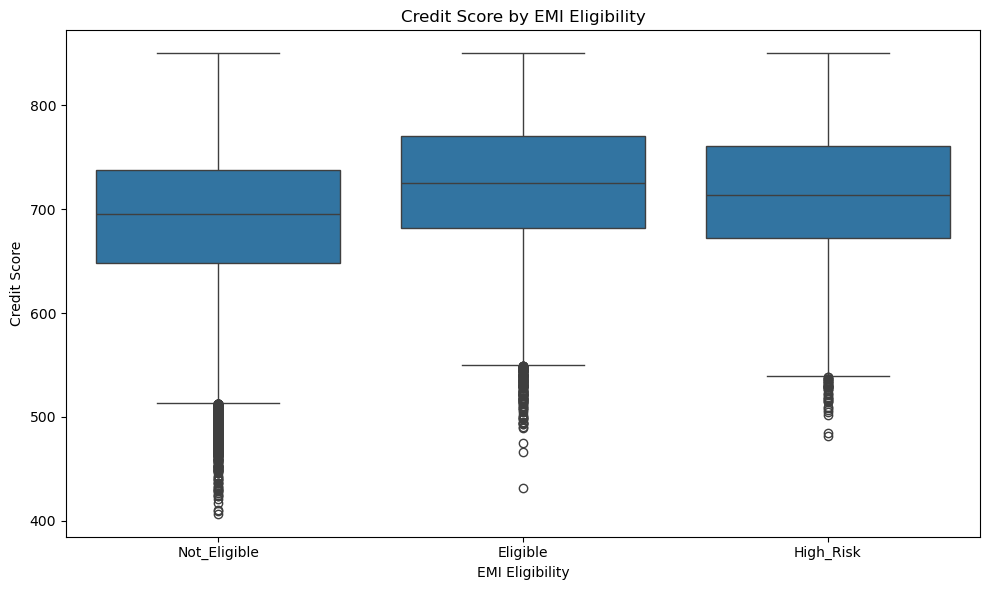

In [109]:
# ============================================================
# STEP 44: CREDIT SCORE VS EMI ELIGIBILITY
# ============================================================

# Calculate summary statistics for credit score
# within each EMI eligibility category.
credit_summary = (
    df_clean
    .groupby("emi_eligibility")["credit_score"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Credit Score by EMI Eligibility:")
print(credit_summary)


# ------------------------------------------------------------
# Create a box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="credit_score"
)

plt.title("Credit Score by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Credit Score")

plt.tight_layout()
plt.show()

Credit Score vs EMI Eligibility: Eligible customers have the highest average credit score (725.17), followed by High_Risk customers (715.69), while Not_Eligible customers have the lowest average credit score (693.65). The results indicate that higher credit scores are associated with better EMI eligibility in the dataset.

Requested Loan Amount by EMI Eligibility:
                  count       mean    median      min        max
emi_eligibility                                                 
Eligible          74444  155361.20  111000.0  10000.0  1499000.0
High_Risk         17488  261358.25  185000.0  10000.0  1499000.0
Not_Eligible     312868  428250.65  288000.0  10000.0  1500000.0


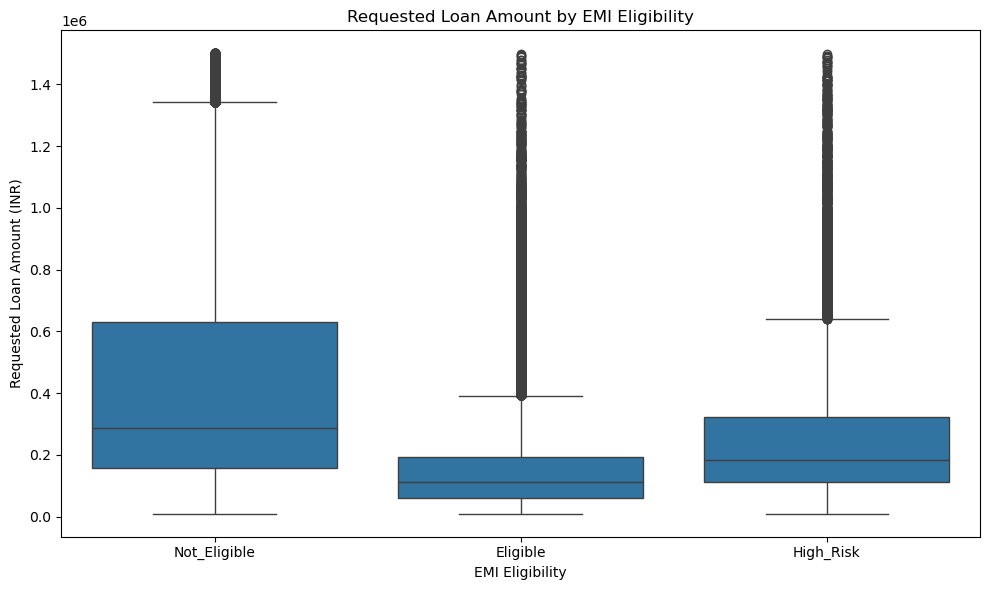

In [110]:
# ============================================================
# STEP 45: REQUESTED LOAN AMOUNT VS EMI ELIGIBILITY
# ============================================================

# Calculate summary statistics for requested loan amount
# within each EMI eligibility category.
loan_amount_summary = (
    df_clean
    .groupby("emi_eligibility")["requested_amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Requested Loan Amount by EMI Eligibility:")
print(loan_amount_summary)


# ------------------------------------------------------------
# Create the box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="requested_amount"
)

plt.title("Requested Loan Amount by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Requested Loan Amount (INR)")

plt.tight_layout()
plt.show()

Requested Loan Amount vs EMI Eligibility: Eligible customers have the lowest average requested loan amount at ₹1.55 lakh, while Not_Eligible customers have the highest average requested amount at ₹4.28 lakh. High_Risk customers fall between the two groups. This shows a strong descriptive relationship between requested loan amount and EMI eligibility, with larger requested amounts being associated with lower eligibility in this dataset.

Requested Tenure by EMI Eligibility:
                  count   mean  median  min  max
emi_eligibility                                 
Eligible          74444  29.65    25.0    3   84
High_Risk         17488  30.24    26.0    3   84
Not_Eligible     312868  28.94    24.0    3   84


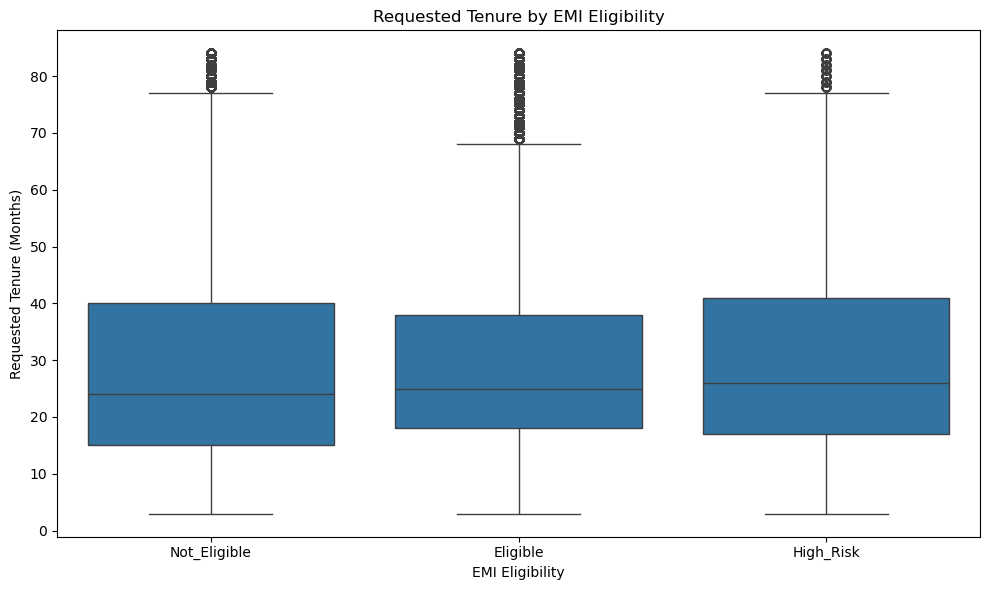

In [111]:
# ============================================================
# STEP 46: REQUESTED TENURE VS EMI ELIGIBILITY
# ============================================================

# Calculate summary statistics for requested tenure
# within each EMI eligibility category.
tenure_summary = (
    df_clean
    .groupby("emi_eligibility")["requested_tenure"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Requested Tenure by EMI Eligibility:")
print(tenure_summary)


# ------------------------------------------------------------
# Create the box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="requested_tenure"
)

plt.title("Requested Tenure by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Requested Tenure (Months)")

plt.tight_layout()
plt.show()

Requested Tenure vs EMI Eligibility: The average requested tenure is similar across all three eligibility categories, ranging from 28.94 to 30.24 months. High_Risk customers have the highest average tenure, while Not_Eligible customers have the lowest. Overall, requested tenure does not show a strong descriptive difference across EMI eligibility groups.

Years of Employment by EMI Eligibility:
                  count  mean  median  min   max
emi_eligibility                                 
Eligible          74444  5.58     3.4  0.5  36.0
High_Risk         17488  5.53     3.3  0.5  36.0
Not_Eligible     312868  5.30     3.1  0.5  36.0


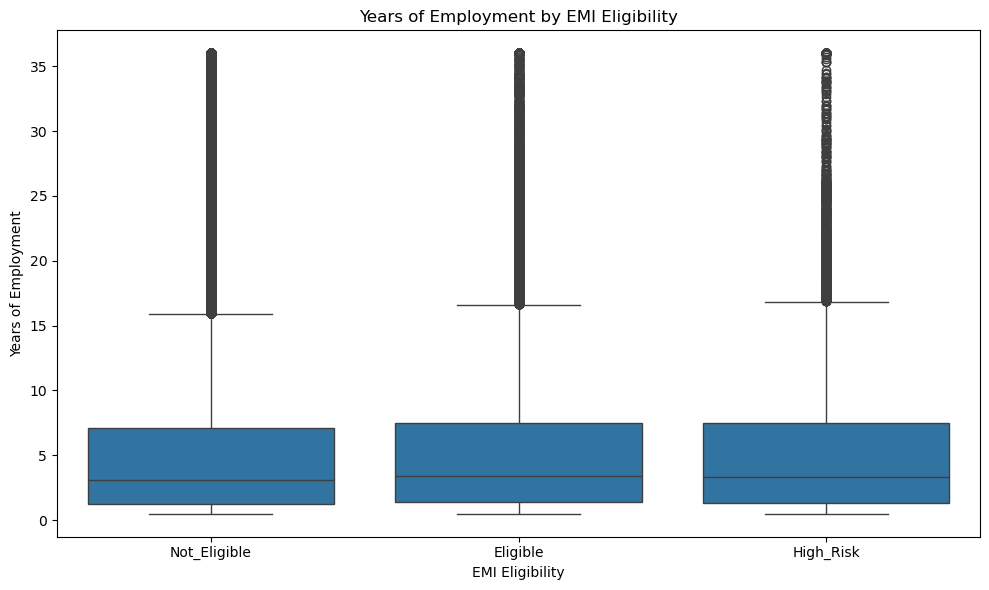

In [112]:
# ============================================================
# STEP 47: YEARS OF EMPLOYMENT VS EMI ELIGIBILITY
# ============================================================

# Calculate summary statistics for years of employment
# within each EMI eligibility category.
employment_years_summary = (
    df_clean
    .groupby("emi_eligibility")["years_of_employment"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Years of Employment by EMI Eligibility:")
print(employment_years_summary)


# ------------------------------------------------------------
# Create the box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="years_of_employment"
)

plt.title("Years of Employment by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Years of Employment")

plt.tight_layout()
plt.show()

Years of Employment vs EMI Eligibility: Eligible customers have the highest average employment experience at 5.58 years, followed by High_Risk customers at 5.53 years and Not_Eligible customers at 5.30 years. However, the differences are relatively small, suggesting that years of employment alone does not strongly differentiate EMI eligibility in this dataset.

Bank Balance by EMI Eligibility:
                  count       mean    median      min        max
emi_eligibility                                                 
Eligible          74444  337758.97  293600.0  10700.0  1717300.0
High_Risk         17488  293116.65  251650.0   9500.0  1500500.0
Not_Eligible     312868  215280.89  177500.0   6100.0  1532400.0


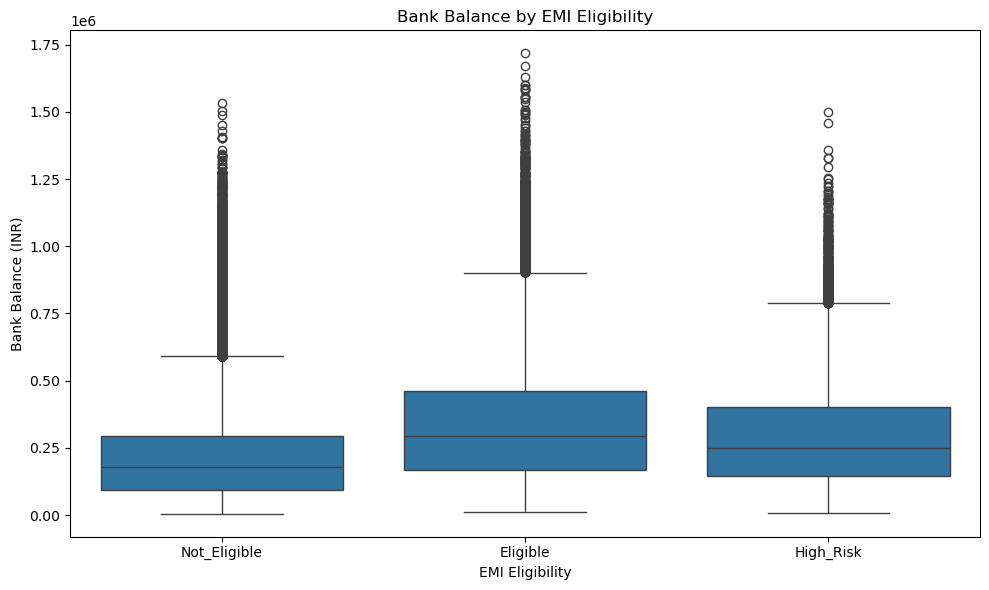

In [113]:
# ============================================================
# STEP 48: BANK BALANCE VS EMI ELIGIBILITY
# ============================================================

# Calculate summary statistics for bank balance
# within each EMI eligibility category.
bank_balance_summary = (
    df_clean
    .groupby("emi_eligibility")["bank_balance"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Bank Balance by EMI Eligibility:")
print(bank_balance_summary)


# ------------------------------------------------------------
# Create the box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="bank_balance"
)

plt.title("Bank Balance by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Bank Balance (INR)")

plt.tight_layout()
plt.show()

Bank Balance vs EMI Eligibility: Eligible customers have the highest average bank balance of ₹3.38 lakh, followed by High_Risk customers at ₹2.93 lakh. Not_Eligible customers have the lowest average bank balance at ₹2.15 lakh. The same pattern is observed in the median values, suggesting that higher bank balances are associated with better EMI eligibility in the dataset.

Emergency Fund by EMI Eligibility:
                  count       mean    median     min       max
emi_eligibility                                               
Eligible          74444  135511.70  110800.0  2300.0  890600.0
High_Risk         17488  118226.32   95200.0  3100.0  724000.0
Not_Eligible     312868   86180.14   66800.0  1400.0  891500.0


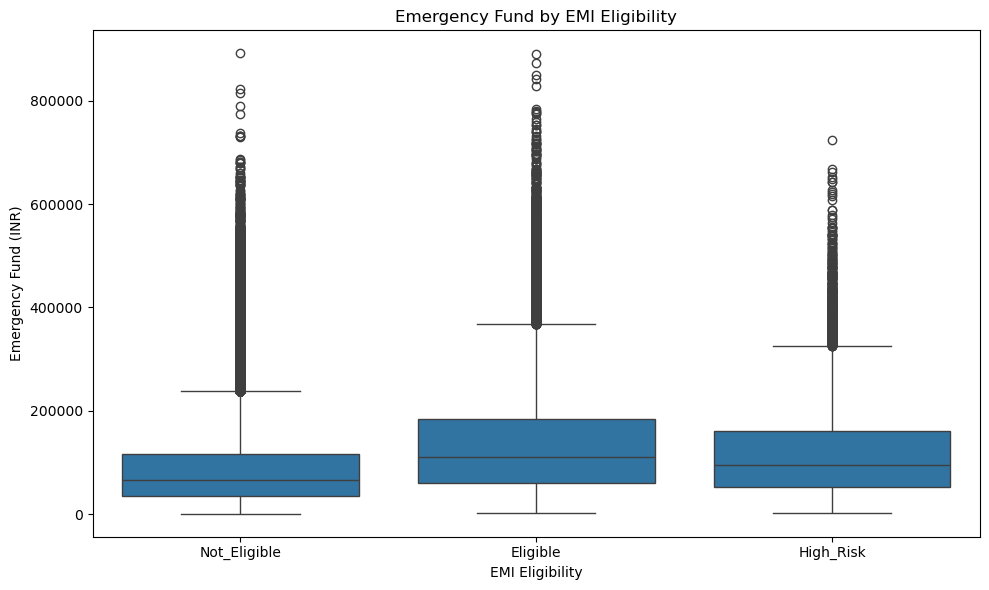

In [114]:
# ============================================================
# STEP 49: EMERGENCY FUND VS EMI ELIGIBILITY
# ============================================================

# Calculate summary statistics for emergency fund
# within each EMI eligibility category.
emergency_fund_summary = (
    df_clean
    .groupby("emi_eligibility")["emergency_fund"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Emergency Fund by EMI Eligibility:")
print(emergency_fund_summary)


# ------------------------------------------------------------
# Create the box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="emergency_fund"
)

plt.title("Emergency Fund by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Emergency Fund (INR)")

plt.tight_layout()
plt.show()

Emergency Fund vs EMI Eligibility: Eligible customers have the highest average emergency fund at ₹1.36 lakh, followed by High_Risk customers at ₹1.18 lakh. Not_Eligible customers have the lowest average emergency fund at ₹86,180. The same pattern is observed in the median values, suggesting that customers with greater emergency funds tend to have better EMI eligibility in the dataset.

Maximum Monthly EMI by EMI Eligibility:
                  count      mean   median    min      max
emi_eligibility                                           
Eligible          74444  15911.96  13840.0  694.4  91040.4
High_Risk         17488  11864.75  10285.0  500.0  65718.0
Not_Eligible     312868   4301.70   2464.0  500.0  62073.0


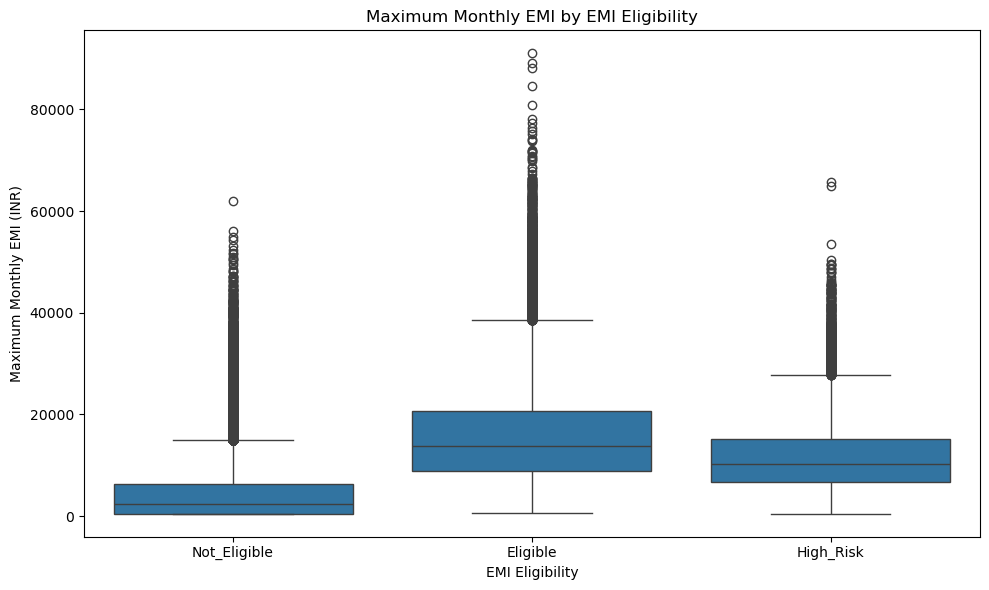

In [115]:
# ============================================================
# STEP 50: MAXIMUM MONTHLY EMI VS EMI ELIGIBILITY
# ============================================================

# Calculate summary statistics for maximum monthly EMI
# within each EMI eligibility category.
max_emi_summary = (
    df_clean
    .groupby("emi_eligibility")["max_monthly_emi"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Maximum Monthly EMI by EMI Eligibility:")
print(max_emi_summary)


# ------------------------------------------------------------
# Create the box plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="max_monthly_emi"
)

plt.title("Maximum Monthly EMI by EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Maximum Monthly EMI (INR)")

plt.tight_layout()
plt.show()

Maximum Monthly EMI vs EMI Eligibility: Eligible customers have the highest average maximum monthly EMI capacity at ₹15,911.96, followed by High_Risk customers at ₹11,864.75. Not_Eligible customers have a substantially lower average of ₹4,301.70. This indicates a strong relationship between maximum EMI capacity and EMI eligibility in the dataset.

Correlation Matrix:


,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,max_monthly_emi,total_monthly_expenses
age,1.00,-0.00,0.48,0.00,0.21,0.21,0.06,0.04,-0.00,-0.00,-0.00,-0.00,0.08,-0.00,-0.00,0.00,0.00,-0.00,0.03
monthly_salary,-0.00,1.00,-0.00,0.21,-0.00,-0.00,-0.00,-0.00,0.54,0.59,0.51,0.21,0.09,0.42,0.38,-0.00,-0.00,0.38,0.49
years_of_employment,0.48,-0.00,1.00,0.00,0.10,0.10,0.03,0.02,-0.00,-0.00,-0.00,-0.00,0.15,-0.00,-0.00,0.00,-0.00,0.03,0.01
monthly_rent,0.00,0.21,0.00,1.00,-0.00,-0.00,-0.00,0.00,0.27,0.30,0.25,0.10,0.04,0.21,0.19,-0.00,0.00,-0.17,0.63
family_size,0.21,-0.00,0.10,-0.00,1.00,1.00,0.18,0.11,-0.00,-0.00,-0.00,-0.00,0.03,-0.00,-0.00,0.00,-0.00,-0.06,0.08
dependents,0.21,-0.00,0.10,-0.00,1.00,1.00,0.18,0.11,-0.00,-0.00,-0.00,-0.00,0.03,-0.00,-0.00,0.00,-0.00,-0.06,0.08
school_fees,0.06,-0.00,0.03,-0.00,0.18,0.18,1.00,0.05,0.00,-0.00,0.00,-0.00,0.01,-0.00,-0.00,0.00,0.00,-0.22,0.27
college_fees,0.04,-0.00,0.02,0.00,0.11,0.11,0.05,1.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.26,0.37
travel_expenses,-0.00,0.54,-0.00,0.27,-0.00,-0.00,0.00,-0.00,1.00,0.77,0.67,0.27,0.12,0.55,0.50,-0.00,-0.00,0.44,0.70
groceries_utilities,-0.00,0.59,-0.00,0.30,-0.00,-0.00,-0.00,-0.00,0.77,1.00,0.73,0.30,0.13,0.60,0.55,0.00,-0.00,0.48,0.76


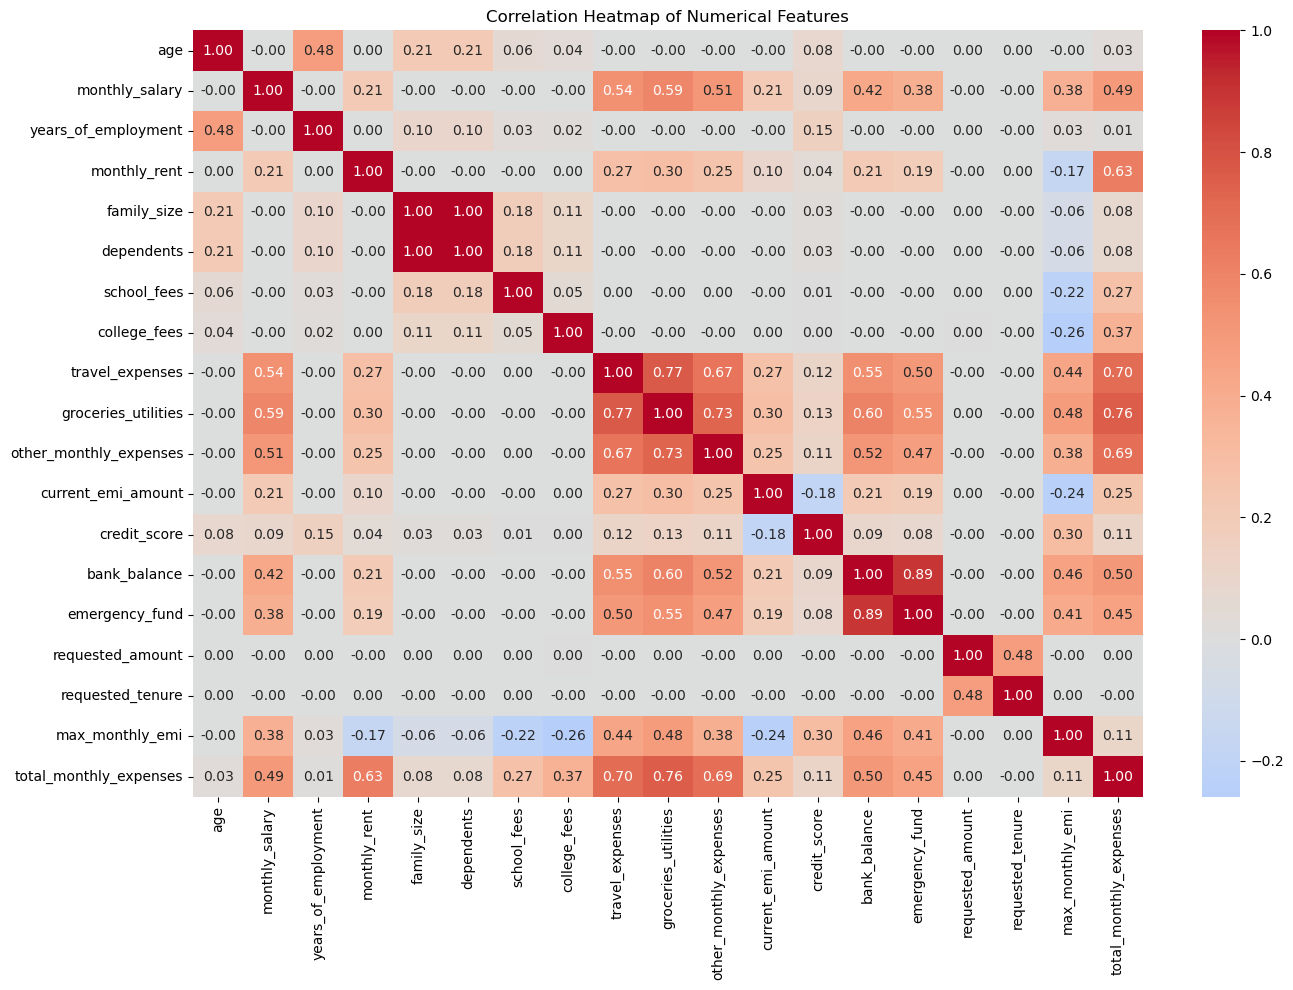

In [116]:
# ============================================================
# STEP 51: CORRELATION ANALYSIS
# ============================================================

# Select only numerical columns for correlation analysis.
numerical_df = df_clean.select_dtypes(include=["int64", "float64"])

# Calculate the Pearson correlation matrix.
correlation_matrix = numerical_df.corr()

# Display the correlation matrix.
print("Correlation Matrix:")
display(correlation_matrix.round(2))


# ------------------------------------------------------------
# Create the correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [117]:
# ============================================================
# STEP 52: OUTLIER ANALYSIS
# ============================================================

# Select numerical columns for outlier analysis.
numerical_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

# Create an empty dictionary to store outlier counts.
outlier_counts = {}

# ------------------------------------------------------------
# Calculate outliers using the IQR method
# ------------------------------------------------------------

for column in numerical_columns:

    # Calculate the first quartile (Q1).
    Q1 = df_clean[column].quantile(0.25)

    # Calculate the third quartile (Q3).
    Q3 = df_clean[column].quantile(0.75)

    # Calculate the Interquartile Range.
    IQR = Q3 - Q1

    # Calculate lower and upper boundaries.
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count observations outside these boundaries.
    outliers = (
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ).sum()

    # Store the count.
    outlier_counts[column] = outliers


# ------------------------------------------------------------
# Display outlier counts
# ------------------------------------------------------------

outlier_summary = pd.DataFrame(
    list(outlier_counts.items()),
    columns=["Column", "Outlier_Count"]
)

# Calculate percentage of outliers.
outlier_summary["Outlier_Percentage"] = (
    outlier_summary["Outlier_Count"]
    / len(df_clean)
    * 100
).round(2)

# Sort from highest to lowest number of outliers.
outlier_summary = outlier_summary.sort_values(
    by="Outlier_Count",
    ascending=False
)

print("Outlier Analysis using IQR Method:")
display(outlier_summary)

Outlier Analysis using IQR Method:


,Column,Outlier_Count,Outlier_Percentage
7,college_fees,48000,11.86
15,requested_amount,25883,6.39
2,years_of_employment,22891,5.65
14,emergency_fund,17790,4.39
11,current_emi_amount,17351,4.29
17,max_monthly_emi,17268,4.27
10,other_monthly_expenses,13518,3.34
13,bank_balance,13499,3.33
3,monthly_rent,12720,3.14
8,travel_expenses,12465,3.08


In [118]:
# ============================================================
# STEP 53: FINAL EDA SUMMARY
# ============================================================

# Select the most important numerical features for the summary.
important_features = [
    "monthly_salary",
    "current_emi_amount",
    "total_monthly_expenses",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "years_of_employment",
    "max_monthly_emi"
]

# Calculate the mean of each feature for every EMI
# eligibility category.
eda_summary = (
    df_clean
    .groupby("emi_eligibility")[important_features]
    .mean()
    .round(2)
)

print("Final EDA Summary - Mean Values by EMI Eligibility:")
display(eda_summary)

Final EDA Summary - Mean Values by EMI Eligibility:


,monthly_salary,current_emi_amount,total_monthly_expenses,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,years_of_employment,max_monthly_emi
emi_eligibility,,,,,,,,,,
Eligible,78860.94,2405.85,42497.18,725.17,337758.97,135511.70,155361.20,29.65,5.58,15911.96
High_Risk,70197.67,3088.11,39640.74,715.69,293116.65,118226.32,261358.25,30.24,5.53,11864.75
Not_Eligible,54257.63,5133.36,39550.31,693.65,215280.89,86180.14,428250.65,28.94,5.30,4301.70


Final EDA findings

Your results show some strong patterns:

Monthly salary: Eligible customers have the highest mean salary (₹78,860.94), while Not_Eligible customers have the lowest (₹54,257.63).

Credit score: Eligible customers have the highest average credit score (725.17), compared with 693.65 for Not_Eligible.

Bank balance: Eligible customers have a much higher average bank balance (₹3.38 lakh) than Not_Eligible (₹2.15 lakh).

Emergency fund: Eligible customers average ₹1.36 lakh, compared with ₹86,180 for Not_Eligible.

Requested amount: Not_Eligible customers request much larger amounts on average (₹4.28 lakh) than Eligible customers (₹1.55 lakh).

Current EMI: Not_Eligible customers have the highest average current EMI (₹5,133.36).

Maximum monthly EMI: Eligible customers have a much higher maximum EMI capacity (₹15,911.96) than Not_Eligible (₹4,301.70).

Requested tenure and years of employment show relatively small differences between groups.

In [119]:
# ============================================================
# STEP 54: FEATURE SELECTION FOR EMI ELIGIBILITY PREDICTION
# ============================================================

# Define the target variable.
# This is what our machine learning model will predict.
target = "emi_eligibility"


# ------------------------------------------------------------
# Select input features
# ------------------------------------------------------------

features = [
    "age",
    "gender",
    "marital_status",
    "education",
    "monthly_salary",
    "employment_type",
    "years_of_employment",
    "company_type",
    "house_type",
    "monthly_rent",
    "dependents",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "existing_loans",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "emi_scenario",
    "requested_amount",
    "requested_tenure"
]


# ------------------------------------------------------------
# Create X and y
# ------------------------------------------------------------

X = df_clean[features]
y = df_clean[target]


# ------------------------------------------------------------
# Display the results
# ------------------------------------------------------------

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nInput Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(y.name)

print("\nTarget Distribution:")
print(y.value_counts())

Feature Matrix Shape: (404800, 24)
Target Shape: (404800,)

Input Features:
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure']

Target Variable:
emi_eligibility

Target Distribution:
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64


In [120]:
# ============================================================
# STEP 55: TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Split the dataset into input features (X) and target (y).
# 80% of the data will be used for training.
# 20% will be used for testing.
#
# stratify=y ensures that the proportion of
# Eligible, High_Risk, and Not_Eligible remains similar
# in both training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# Display the shapes of the resulting datasets
# ------------------------------------------------------------

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)


# ------------------------------------------------------------
# Check target distribution in training data
# ------------------------------------------------------------

print("\nTraining Target Distribution:")
print(y_train.value_counts())


# ------------------------------------------------------------
# Check target distribution in testing data
# ------------------------------------------------------------

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Feature Shape: (323840, 24)
Testing Feature Shape: (80960, 24)

Training Target Shape: (323840,)
Testing Target Shape: (80960,)

Training Target Distribution:
emi_eligibility
Not_Eligible    250294
Eligible         59555
High_Risk        13991
Name: count, dtype: int64

Testing Target Distribution:
emi_eligibility
Not_Eligible    62574
Eligible        14889
High_Risk        3497
Name: count, dtype: int64


In [121]:
# ============================================================
# STEP 56: ENCODE CATEGORICAL FEATURES
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


# ------------------------------------------------------------
# Identify categorical and numerical columns
# ------------------------------------------------------------

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()


# Display the columns
print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


# ------------------------------------------------------------
# Create the preprocessing transformer
# ------------------------------------------------------------

# OneHotEncoder converts categorical values into binary columns.
#
# handle_unknown="ignore" ensures that if a category appears
# in the test data but was not present during training,
# the model will not produce an error.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)


# ------------------------------------------------------------
# Fit the encoder ONLY on training data
# ------------------------------------------------------------

X_train_encoded = preprocessor.fit_transform(X_train)


# ------------------------------------------------------------
# Transform the test data using the same encoder
# ------------------------------------------------------------

X_test_encoded = preprocessor.transform(X_test)


# ------------------------------------------------------------
# Display the resulting shapes
# ------------------------------------------------------------

print("\nEncoded Training Shape:", X_train_encoded.shape)
print("Encoded Testing Shape:", X_test_encoded.shape)

Categorical Features:
['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']

Numerical Features:
['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure']

Encoded Training Shape: (323840, 42)
Encoded Testing Shape: (80960, 42)


In [122]:
# ============================================================
# STEP 57: FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# Create the scaler
# ------------------------------------------------------------

# StandardScaler transforms numerical features so that
# they have approximately:
# Mean = 0
# Standard Deviation = 1

scaler = StandardScaler()


# ------------------------------------------------------------
# Identify the numerical feature positions
# ------------------------------------------------------------

# The ColumnTransformer places:
# 1. One-hot encoded categorical features first
# 2. Numerical features after them
#
# Therefore, the last len(numerical_features) columns
# correspond to the numerical features.

num_features_count = len(numerical_features)

num_start_index = X_train_encoded.shape[1] - num_features_count


# ------------------------------------------------------------
# Scale ONLY numerical columns
# ------------------------------------------------------------

X_train_encoded[:, num_start_index:] = scaler.fit_transform(
    X_train_encoded[:, num_start_index:]
)

X_test_encoded[:, num_start_index:] = scaler.transform(
    X_test_encoded[:, num_start_index:]
)


# ------------------------------------------------------------
# Check the resulting shapes
# ------------------------------------------------------------

print("Scaled Training Shape:", X_train_encoded.shape)
print("Scaled Testing Shape:", X_test_encoded.shape)


# ------------------------------------------------------------
# Check a few scaled numerical values
# ------------------------------------------------------------

print("\nSample of Scaled Numerical Features:")
print(X_train_encoded[:5, num_start_index:])

Scaled Training Shape: (323840, 42)
Scaled Testing Shape: (80960, 42)

Sample of Scaled Numerical Features:
[[-0.09464835  0.39348319 -0.09256151 -0.67065607  0.05467107 -0.91320741
  -0.5555526   0.29999841  0.0870348  -0.31426759  0.56241009  0.72434503
   1.2427526   1.48826776 -0.8425382   0.87715054]
 [-1.27667512 -0.58977912 -0.50436444 -0.67065607 -0.87573399  0.37050223
  -0.5555526  -0.82143019 -0.47195546 -0.82470559  0.60508904  0.18903461
  -0.46460355 -0.68269811  2.33232272 -0.11743513]
 [ 2.05449124 -0.04506104 -0.78439043  1.09129711  0.05467107 -0.24172852
   0.93408053 -0.64436251 -0.41462313 -0.15891689 -0.64682674  0.53103849
  -0.06002721  0.13804794 -0.14957769 -0.72523749]
 [ 0.97992145 -1.11390871 -0.45494808 -0.67065607  0.05467107  1.23947491
  -0.5555526   2.07067513  0.94701982  1.41678302 -0.64682674  1.18530678
   0.97614998  0.72799774 -0.33514034  0.15883866]
 [ 0.97992145  0.85049243  1.94998102 -0.67065607  0.05467107  1.21972553
   2.69704083  0.06390

## Step 58 — Train the First Classification Model

In [123]:
# ============================================================
# STEP 58: LOGISTIC REGRESSION - BASELINE MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# Create the Logistic Regression model
# ------------------------------------------------------------

# class_weight="balanced" gives more importance to minority
# classes such as High_Risk.
#
# This is important because our target classes are imbalanced.

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)


# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

print("Training Logistic Regression model...")

logistic_model.fit(
    X_train_encoded,
    y_train
)

print("Model training completed successfully!")


# ------------------------------------------------------------
# Make predictions on the test data
# ------------------------------------------------------------

y_pred_logistic = logistic_model.predict(
    X_test_encoded
)

print("\nPredictions generated successfully!")

# Display first 20 predictions
print("\nFirst 20 Predictions:")
print(y_pred_logistic[:20])

Training Logistic Regression model...
Model training completed successfully!

Predictions generated successfully!

First 20 Predictions:
['Eligible' 'Not_Eligible' 'High_Risk' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'Not_Eligible' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'High_Risk' 'Eligible' 'Eligible' 'High_Risk'
 'Not_Eligible' 'High_Risk' 'High_Risk' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible']


Logistic Regression Accuracy:
0.7867

Classification Report:
              precision    recall  f1-score   support

    Eligible       0.82      0.73      0.78     14889
   High_Risk       0.14      0.65      0.23      3497
Not_Eligible       0.98      0.81      0.89     62574

    accuracy                           0.79     80960
   macro avg       0.65      0.73      0.63     80960
weighted avg       0.92      0.79      0.84     80960


Confusion Matrix:
[[10934  3530   425]
 [  810  2290   397]
 [ 1532 10578 50464]]


<Figure size 800x600 with 0 Axes>

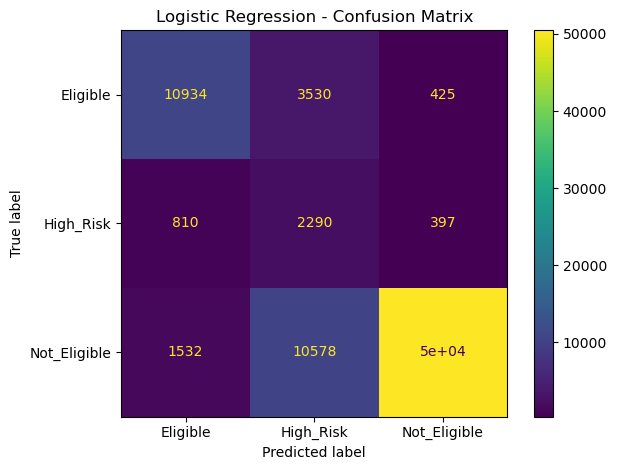

In [124]:
# ============================================================
# STEP 59: LOGISTIC REGRESSION MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Calculate Accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:")
print(f"{accuracy:.4f}")


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("\nConfusion Matrix:")
print(cm)


# ------------------------------------------------------------
# Display Confusion Matrix as a Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()

The overall accuracy of 78.67% looks good, but we shouldn't rely on accuracy alone.

The biggest problem is High_Risk:

Recall = 65% → good; the model catches many High_Risk customers.
Precision = 14% → poor; many customers predicted as High_Risk are actually from another class.
F1 = 0.23 → weak overall performance for this class.

This happens largely because High_Risk is the smallest class.

The confusion matrix also shows that many Not_Eligible customers are being predicted as High_Risk:

Actual Not_Eligible → Predicted High_Risk = 10,578

So 78.67% accuracy is not enough to call this a good final model.

## Random Forest

In [62]:
# ============================================================
# STEP 60: RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# Create the Random Forest model
# ------------------------------------------------------------

# class_weight="balanced" helps give more importance
# to minority classes such as High_Risk.

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# Train the model
# ------------------------------------------------------------

print("Training Random Forest model...")

random_forest_model.fit(
    X_train_encoded,
    y_train
)

print("Random Forest training completed successfully!")


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

y_pred_rf = random_forest_model.predict(
    X_test_encoded
)

print("\nPredictions generated successfully!")

print("\nFirst 20 Predictions:")
print(y_pred_rf[:20])

Training Random Forest model...
Random Forest training completed successfully!

Predictions generated successfully!

First 20 Predictions:
['Not_Eligible' 'Not_Eligible' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'Not_Eligible' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'Not_Eligible' 'Not_Eligible' 'Eligible' 'Eligible'
 'Not_Eligible' 'Not_Eligible' 'Eligible' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'Not_Eligible']


Random Forest Accuracy:
0.9165

Classification Report:
              precision    recall  f1-score   support

    Eligible       0.90      0.81      0.86     14889
   High_Risk       0.98      0.01      0.03      3497
Not_Eligible       0.92      0.99      0.95     62574

    accuracy                           0.92     80960
   macro avg       0.93      0.61      0.61     80960
weighted avg       0.92      0.92      0.90     80960


Confusion Matrix:
[[12105     1  2783]
 [  778    47  2672]
 [  528     0 62046]]


<Figure size 800x600 with 0 Axes>

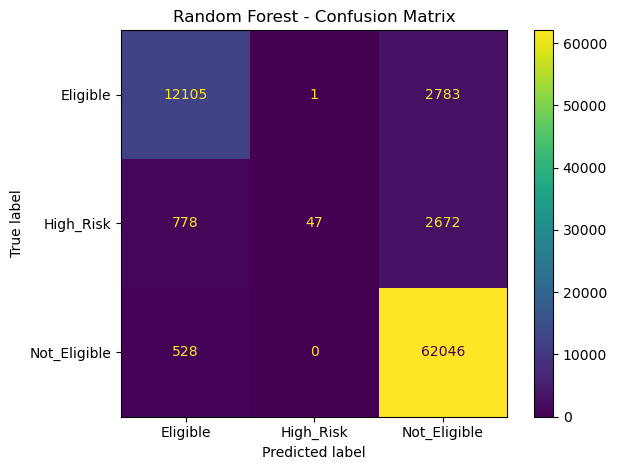

In [63]:
# ============================================================
# STEP 61: RANDOM FOREST MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Calculate Accuracy
# ------------------------------------------------------------

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:")
print(f"{rf_accuracy:.4f}")


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print("\nConfusion Matrix:")
print(rf_cm)


# ------------------------------------------------------------
# Display Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=random_forest_model.classes_
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

At first glance, Random Forest looks much better than Logistic Regression because accuracy increased from 78.67% → 91.65%.

In [125]:
# ============================================================
# STEP 62: BALANCED RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# Create a balanced Random Forest
# ------------------------------------------------------------

# balanced_subsample calculates class weights separately
# for each bootstrap sample.
#
# This can help the model pay more attention to minority
# classes such as High_Risk.

balanced_rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# Train the balanced Random Forest
# ------------------------------------------------------------

print("Training Balanced Random Forest model...")

balanced_rf_model.fit(
    X_train_encoded,
    y_train
)

print("Balanced Random Forest training completed successfully!")


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

y_pred_balanced_rf = balanced_rf_model.predict(
    X_test_encoded
)

print("\nPredictions generated successfully!")

print("\nFirst 20 Predictions:")
print(y_pred_balanced_rf[:20])

Training Balanced Random Forest model...
Balanced Random Forest training completed successfully!

Predictions generated successfully!

First 20 Predictions:
['Not_Eligible' 'Not_Eligible' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'Not_Eligible' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'Not_Eligible' 'Not_Eligible' 'Eligible' 'Eligible'
 'Not_Eligible' 'Not_Eligible' 'Eligible' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'Not_Eligible']


Balanced Random Forest Accuracy:
0.9173

Classification Report:
              precision    recall  f1-score   support

    Eligible       0.90      0.82      0.86     14889
   High_Risk       1.00      0.01      0.03      3497
Not_Eligible       0.92      0.99      0.95     62574

    accuracy                           0.92     80960
   macro avg       0.94      0.61      0.61     80960
weighted avg       0.92      0.92      0.90     80960


Confusion Matrix:
[[12162     0  2727]
 [  757    47  2693]
 [  521     0 62053]]


<Figure size 800x600 with 0 Axes>

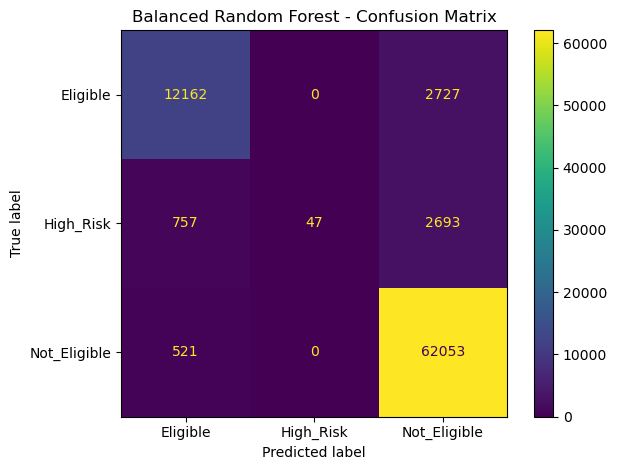

In [126]:
# ============================================================
# STEP 63: EVALUATE BALANCED RANDOM FOREST
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Calculate Accuracy
# ------------------------------------------------------------

balanced_rf_accuracy = accuracy_score(
    y_test,
    y_pred_balanced_rf
)

print("Balanced Random Forest Accuracy:")
print(f"{balanced_rf_accuracy:.4f}")


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_balanced_rf
    )
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

balanced_rf_cm = confusion_matrix(
    y_test,
    y_pred_balanced_rf
)

print("\nConfusion Matrix:")
print(balanced_rf_cm)


# ------------------------------------------------------------
# Display Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=balanced_rf_cm,
    display_labels=balanced_rf_model.classes_
)

disp.plot()

plt.title("Balanced Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

In [127]:
# ============================================================
# STEP 64A: CHECK XGBOOST INSTALLATION
# ============================================================

try:
    import xgboost as xgb
    print("XGBoost is installed.")
    print("XGBoost version:", xgb.__version__)

except ImportError:
    print("XGBoost is not installed.")

XGBoost is not installed.


In [128]:
# ============================================================
# STEP 64: MODEL COMPARISON
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd


# ------------------------------------------------------------
# Calculate metrics for each model
# ------------------------------------------------------------

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_balanced_rf)
    ],

    "Macro Precision": [
        precision_score(y_test, y_pred_logistic, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro"),
        precision_score(y_test, y_pred_balanced_rf, average="macro")
    ],

    "Macro Recall": [
        recall_score(y_test, y_pred_logistic, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro"),
        recall_score(y_test, y_pred_balanced_rf, average="macro")
    ],

    "Macro F1": [
        f1_score(y_test, y_pred_logistic, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_balanced_rf, average="macro")
    ],

    "High_Risk Recall": [
        recall_score(
            y_test,
            y_pred_logistic,
            labels=["High_Risk"],
            average="macro"
        ),
        recall_score(
            y_test,
            y_pred_rf,
            labels=["High_Risk"],
            average="macro"
        ),
        recall_score(
            y_test,
            y_pred_balanced_rf,
            labels=["High_Risk"],
            average="macro"
        )
    ],

    "High_Risk F1": [
        f1_score(
            y_test,
            y_pred_logistic,
            labels=["High_Risk"],
            average="macro"
        ),
        f1_score(
            y_test,
            y_pred_rf,
            labels=["High_Risk"],
            average="macro"
        ),
        f1_score(
            y_test,
            y_pred_balanced_rf,
            labels=["High_Risk"],
            average="macro"
        )
    ]
})


# ------------------------------------------------------------
# Round values for easier reading
# ------------------------------------------------------------

comparison = comparison.round(4)


# ------------------------------------------------------------
# Display comparison
# ------------------------------------------------------------

print("MODEL COMPARISON")
print("=" * 80)

display(comparison)

MODEL COMPARISON


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,High_Risk Recall,High_Risk F1
0,Logistic Regression,0.7867,0.6491,0.7319,0.6310,0.6548,0.2302
1,Random Forest,0.9165,0.9337,0.6060,0.6120,0.0134,0.0265
2,Balanced Random Forest,0.9173,0.9415,0.6073,0.6132,0.0134,0.0265


In [129]:
# ============================================================
# STEP 65: HYPERPARAMETER TUNING - LOGISTIC REGRESSION
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# Create Logistic Regression model
# ------------------------------------------------------------

logistic_tuning_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)


# ------------------------------------------------------------
# Define hyperparameters
# ------------------------------------------------------------

# C controls the strength of regularization.
# Smaller C  -> stronger regularization
# Larger C   -> weaker regularization

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}


# ------------------------------------------------------------
# Create Grid Search
# ------------------------------------------------------------

grid_search = GridSearchCV(
    estimator=logistic_tuning_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)


# ------------------------------------------------------------
# Train Grid Search
# ------------------------------------------------------------

print("Starting Logistic Regression hyperparameter tuning...")

grid_search.fit(
    X_train_encoded,
    y_train
)

print("\nHyperparameter tuning completed!")


# ------------------------------------------------------------
# Display best parameters
# ------------------------------------------------------------

print("\nBest Parameters:")
print(grid_search.best_params_)


# ------------------------------------------------------------
# Display best cross-validation score
# ------------------------------------------------------------

print("\nBest Cross-Validation Macro F1:")
print(round(grid_search.best_score_, 4))


# ------------------------------------------------------------
# Store the best model
# ------------------------------------------------------------

best_logistic_model = grid_search.best_estimator_

print("\nBest Logistic Regression model selected successfully!")

Starting Logistic Regression hyperparameter tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Hyperparameter tuning completed!

Best Parameters:
{'C': 1}

Best Cross-Validation Macro F1:
0.6294

Best Logistic Regression model selected successfully!


Predictions generated successfully!

Tuned Logistic Regression Accuracy:
0.7867

Classification Report:
              precision    recall  f1-score   support

    Eligible       0.82      0.73      0.78     14889
   High_Risk       0.14      0.65      0.23      3497
Not_Eligible       0.98      0.81      0.89     62574

    accuracy                           0.79     80960
   macro avg       0.65      0.73      0.63     80960
weighted avg       0.92      0.79      0.84     80960


Confusion Matrix:
[[10934  3530   425]
 [  810  2290   397]
 [ 1532 10578 50464]]


<Figure size 800x600 with 0 Axes>

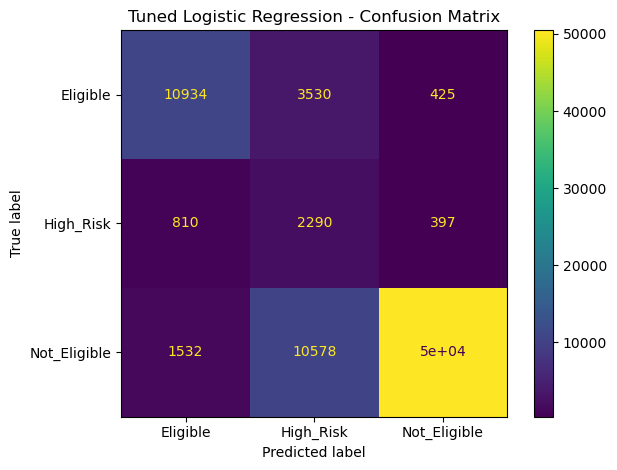

In [130]:
# ============================================================
# STEP 66: EVALUATE TUNED LOGISTIC REGRESSION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Generate predictions using the best tuned model
# ------------------------------------------------------------

y_pred_tuned_logistic = best_logistic_model.predict(
    X_test_encoded
)

print("Predictions generated successfully!")


# ------------------------------------------------------------
# Calculate Accuracy
# ------------------------------------------------------------

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_logistic
)

print("\nTuned Logistic Regression Accuracy:")
print(f"{tuned_accuracy:.4f}")


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_tuned_logistic
    )
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

tuned_cm = confusion_matrix(
    y_test,
    y_pred_tuned_logistic
)

print("\nConfusion Matrix:")
print(tuned_cm)


# ------------------------------------------------------------
# Display Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=best_logistic_model.classes_
)

disp.plot()

plt.title("Tuned Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()

In [131]:
# ============================================================
# STEP 67: LOGISTIC REGRESSION FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Get feature names after one-hot encoding
# ------------------------------------------------------------

feature_names = preprocessor.get_feature_names_out()


# ------------------------------------------------------------
# Get coefficients from the trained Logistic Regression model
# ------------------------------------------------------------

coefficients = best_logistic_model.coef_


# ------------------------------------------------------------
# Create a DataFrame containing coefficients
# ------------------------------------------------------------

coefficient_df = pd.DataFrame(
    coefficients.T,
    index=feature_names,
    columns=best_logistic_model.classes_
)


# ------------------------------------------------------------
# Calculate overall importance
# ------------------------------------------------------------

# Absolute coefficient values indicate how strongly
# each feature contributes to the prediction.

coefficient_df["Overall_Importance"] = (
    coefficient_df
    .abs()
    .mean(axis=1)
)


# ------------------------------------------------------------
# Sort features by overall importance
# ------------------------------------------------------------

coefficient_df = coefficient_df.sort_values(
    "Overall_Importance",
    ascending=False
)


# ------------------------------------------------------------
# Display top 20 important features
# ------------------------------------------------------------

print("Top 20 Most Important Features:")
display(
    coefficient_df.head(20)
)

Top 20 Most Important Features:


,Eligible,High_Risk,Not_Eligible,Overall_Importance
numerical__requested_amount,-3.589993,0.294130,3.295863,2.393329
numerical__requested_tenure,1.424023,0.085670,-1.509693,1.006462
categorical__house_type_Rented,-0.914252,-0.101648,1.015900,0.677267
numerical__college_fees,-0.761584,-0.194446,0.956030,0.637353
categorical__existing_loans_Yes,-0.953750,-0.000092,0.953842,0.635894
numerical__school_fees,-0.529459,-0.128494,0.657952,0.438635
numerical__groceries_utilities,0.532454,0.099313,-0.631767,0.421178
numerical__current_emi_amount,-0.460578,-0.083325,0.543902,0.362602
categorical__emi_scenario_Personal Loan EMI,-0.466876,-0.066839,0.533715,0.355810
numerical__bank_balance,0.476378,0.053318,-0.529696,0.353131


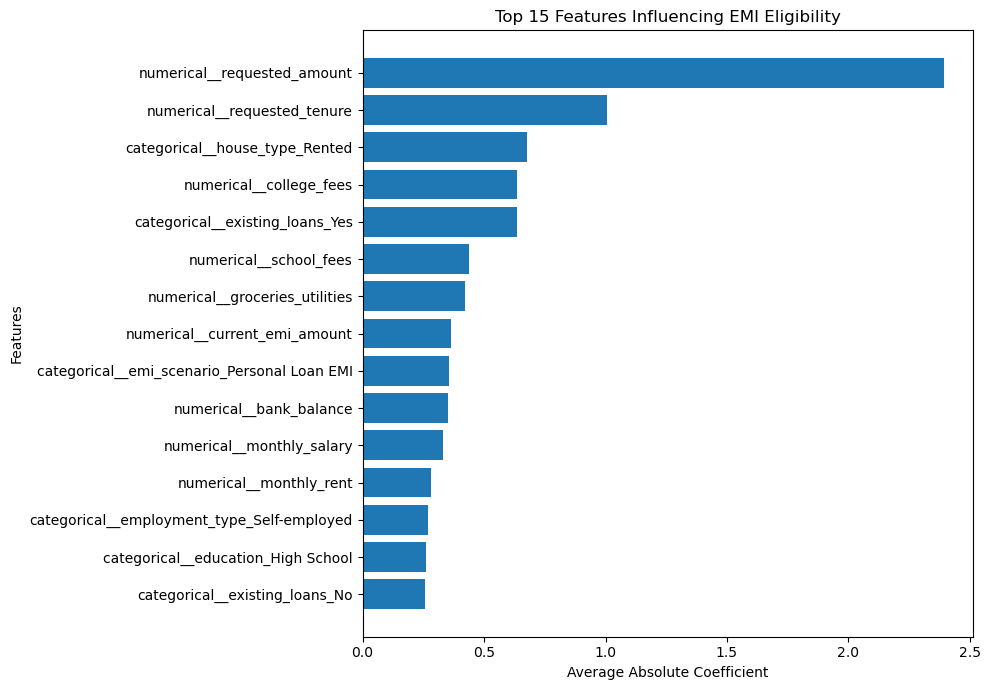

In [132]:
# ============================================================
# STEP 68: TOP 15 FEATURE IMPORTANCE VISUALIZATION
# ============================================================

# Select the 15 most important features
top_features = coefficient_df.head(15).sort_values(
    "Overall_Importance"
)


# ------------------------------------------------------------
# Create the plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.barh(
    top_features.index,
    top_features["Overall_Importance"]
)

plt.xlabel("Average Absolute Coefficient")
plt.ylabel("Features")
plt.title("Top 15 Features Influencing EMI Eligibility")

plt.tight_layout()
plt.show()

In [133]:
# ============================================================
# STEP 69: MULTICLASS ROC-AUC EVALUATION
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# Generate prediction probabilities
# ------------------------------------------------------------

y_proba_logistic = best_logistic_model.predict_proba(
    X_test_encoded
)


# ------------------------------------------------------------
# Convert target labels into binary format
# ------------------------------------------------------------

classes = best_logistic_model.classes_

y_test_binary = label_binarize(
    y_test,
    classes=classes
)


# ------------------------------------------------------------
# Calculate ROC-AUC
# ------------------------------------------------------------

roc_auc = roc_auc_score(
    y_test_binary,
    y_proba_logistic,
    multi_class="ovr",
    average="macro"
)


# ------------------------------------------------------------
# Display ROC-AUC
# ------------------------------------------------------------

print("Multiclass ROC-AUC Score:")
print(f"{roc_auc:.4f}")

Multiclass ROC-AUC Score:
0.9237


The Logistic Regression model achieved 78.67% accuracy and a multiclass ROC-AUC score of 0.9237. The model achieved a High_Risk recall of 65.48%, making it more suitable for identifying high-risk applicants than the Random Forest models tested.

ROC-AUC of 0.9237 does not mean 92.37% prediction accuracy. They measure different things.

In [134]:
# ============================================================
# STEP 70: SAVE FINAL MODEL AND PREPROCESSOR
# ============================================================

import joblib


# ------------------------------------------------------------
# Save the trained Logistic Regression model
# ------------------------------------------------------------

joblib.dump(
    best_logistic_model,
    "emi_logistic_regression_model.pkl"
)


# ------------------------------------------------------------
# Save the preprocessing pipeline
# ------------------------------------------------------------

joblib.dump(
    preprocessor,
    "emi_preprocessor.pkl"
)


print("Final model saved successfully!")
print("Preprocessor saved successfully!")

Final model saved successfully!
Preprocessor saved successfully!


## Step 71 — Test the Model on a New Customer

In [135]:
# ============================================================
# STEP 71: PREDICT EMI ELIGIBILITY FOR A NEW CUSTOMER
# ============================================================

import pandas as pd
import joblib


# ------------------------------------------------------------
# Load the saved model and preprocessor
# ------------------------------------------------------------

model = joblib.load(
    "emi_logistic_regression_model.pkl"
)

preprocessor_loaded = joblib.load(
    "emi_preprocessor.pkl"
)


# ------------------------------------------------------------
# Create details for a new customer
# ------------------------------------------------------------

new_customer = pd.DataFrame([{

    "age": 35,
    "gender": "Male",
    "marital_status": "Married",
    "education": "Graduate",
    "monthly_salary": 60000,
    "employment_type": "Private",
    "years_of_employment": 5,
    "company_type": "MNC",
    "house_type": "Own",
    "monthly_rent": 0,
    "dependents": 2,
    "school_fees": 5000,
    "college_fees": 0,
    "travel_expenses": 5000,
    "groceries_utilities": 12000,
    "other_monthly_expenses": 5000,
    "existing_loans": "No",
    "current_emi_amount": 0,
    "credit_score": 750,
    "bank_balance": 250000,
    "emergency_fund": 100000,
    "emi_scenario": "Personal Loan EMI",
    "requested_amount": 200000,
    "requested_tenure": 24

}])


# ------------------------------------------------------------
# Transform the new customer's data
# ------------------------------------------------------------

new_customer_encoded = preprocessor_loaded.transform(
    new_customer
)


# ------------------------------------------------------------
# Predict EMI eligibility
# ------------------------------------------------------------

prediction = model.predict(
    new_customer_encoded
)


# ------------------------------------------------------------
# Get prediction probabilities
# ------------------------------------------------------------

probabilities = model.predict_proba(
    new_customer_encoded
)


# ------------------------------------------------------------
# Display the result
# ------------------------------------------------------------

print("============================================================")
print("EMI ELIGIBILITY PREDICTION")
print("============================================================")

print("\nPredicted EMI Eligibility:")
print(prediction[0])


print("\nPrediction Probabilities:")

for class_name, probability in zip(
    model.classes_,
    probabilities[0]
):
    print(f"{class_name}: {probability:.2%}")

EMI ELIGIBILITY PREDICTION

Predicted EMI Eligibility:
Not_Eligible

Prediction Probabilities:
Eligible: 0.00%
High_Risk: 0.00%
Not_Eligible: 100.00%


In [136]:
# ============================================================
# STEP 72: CHECK EXACT PREDICTION PROBABILITIES
# ============================================================

print("Exact Prediction Probabilities:")

for class_name, probability in zip(
    model.classes_,
    probabilities[0]
):
    print(f"{class_name}: {probability:.10f}")

Exact Prediction Probabilities:
Eligible: 0.0000000000
High_Risk: 0.0000000000
Not_Eligible: 1.0000000000


In [137]:
# ============================================================
# STEP 73: FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

final_model_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "High_Risk Recall",
        "High_Risk F1",
        "Multiclass ROC-AUC"
    ],

    "Score": [
        0.7867,
        0.6491,
        0.7319,
        0.6310,
        0.6548,
        0.2302,
        0.9237
    ]
})

print("FINAL MODEL PERFORMANCE")
print("=" * 50)

display(final_model_summary)

FINAL MODEL PERFORMANCE


,Metric,Score
0,Accuracy,0.7867
1,Macro Precision,0.6491
2,Macro Recall,0.7319
3,Macro F1,0.6310
4,High_Risk Recall,0.6548
5,High_Risk F1,0.2302
6,Multiclass ROC-AUC,0.9237


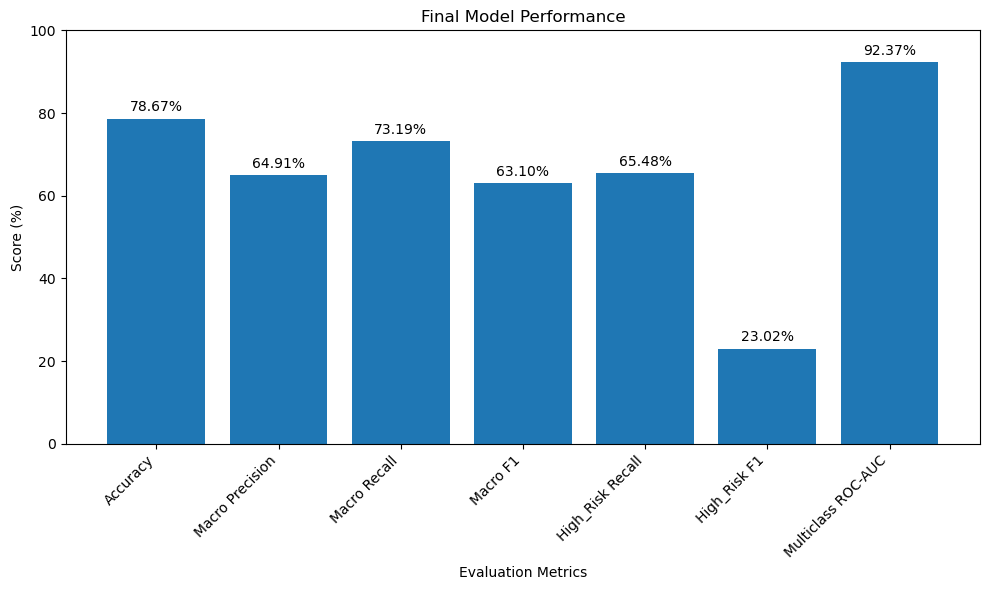

In [138]:
# ============================================================
# STEP 74: FINAL MODEL PERFORMANCE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

# Create a copy of the performance summary
plot_data = final_model_summary.copy()

# Convert scores into percentages
plot_data["Percentage"] = plot_data["Score"] * 100

# Create the bar chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    plot_data["Metric"],
    plot_data["Percentage"]
)

# Add percentage values above each bar
for bar, value in zip(bars, plot_data["Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Final Model Performance")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score (%)")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Step 75 — Save the Final Prediction Result

In [139]:
# ============================================================
# STEP 75: DISPLAY FINAL CUSTOMER PREDICTION
# ============================================================

# Get the predicted class
predicted_class = prediction[0]

# Get the highest probability
confidence = probabilities[0].max()

# Create a result DataFrame
prediction_result = pd.DataFrame({
    "Prediction": [predicted_class],
    "Confidence": [confidence]
})

# Convert confidence to percentage
prediction_result["Confidence (%)"] = (
    prediction_result["Confidence"] * 100
).round(2)

print("FINAL CUSTOMER PREDICTION")
print("=" * 50)

display(prediction_result)

FINAL CUSTOMER PREDICTION


,Prediction,Confidence,Confidence (%)
0,Not_Eligible,1.0,100.0


## Step 76 — Create a Final Model Comparison Graph

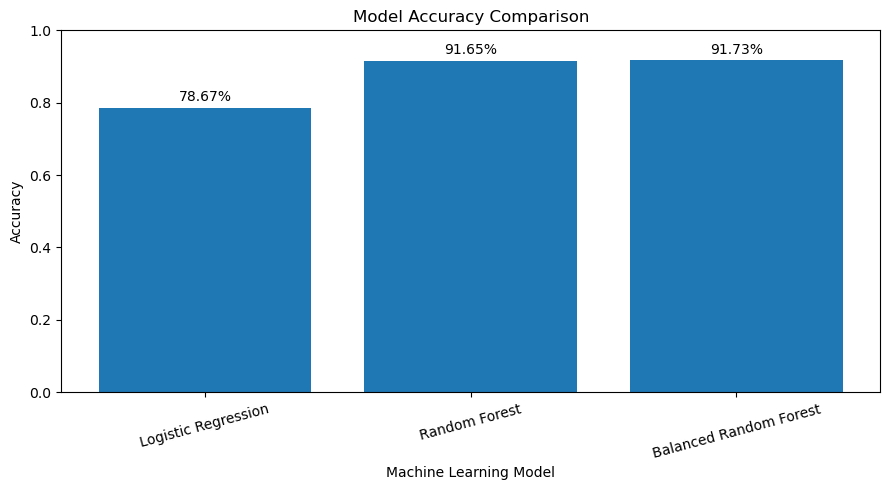

In [140]:
# ============================================================
# STEP 76: MODEL ACCURACY COMPARISON
# ============================================================

import matplotlib.pyplot as plt

# Model names and their accuracy scores
models = [
    "Logistic Regression",
    "Random Forest",
    "Balanced Random Forest"
]

accuracy = [
    0.7867,
    0.9165,
    0.9173
]

# Create bar chart
plt.figure(figsize=(9, 5))

bars = plt.bar(models, accuracy)

# Add accuracy values above bars
for bar, score in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score * 100:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [141]:
# ============================================================
# STEP 77: COMPLETE MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Random Forest"
    ],

    "Accuracy": [
        0.7867,
        0.9165,
        0.9173
    ],

    "Macro Precision": [
        0.6491,
        0.9337,
        0.9415
    ],

    "Macro Recall": [
        0.7319,
        0.6060,
        0.6073
    ],

    "Macro F1": [
        0.6310,
        0.6120,
        0.6132
    ],

    "High_Risk Recall": [
        0.6548,
        0.0134,
        0.0134
    ],

    "High_Risk F1": [
        0.2302,
        0.0265,
        0.0265
    ]
})

print("COMPLETE MODEL COMPARISON")
print("=" * 80)

display(model_comparison)

COMPLETE MODEL COMPARISON


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,High_Risk Recall,High_Risk F1
0,Logistic Regression,0.7867,0.6491,0.7319,0.6310,0.6548,0.2302
1,Random Forest,0.9165,0.9337,0.6060,0.6120,0.0134,0.0265
2,Balanced Random Forest,0.9173,0.9415,0.6073,0.6132,0.0134,0.0265


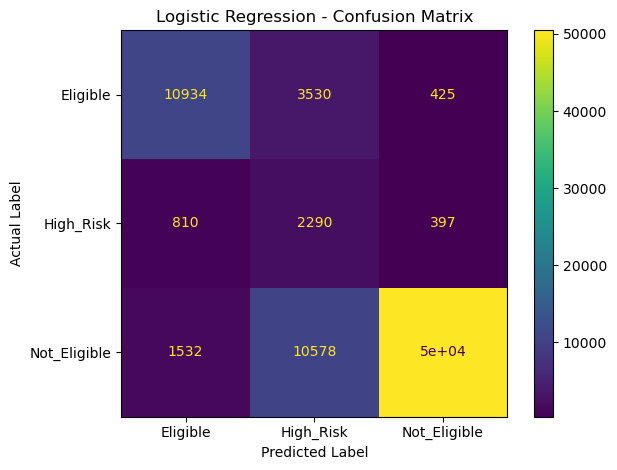

In [143]:
# ============================================================
# STEP 78: LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Confusion matrix obtained from Logistic Regression evaluation
cm = np.array([
    [10934, 3530, 425],
    [810, 2290, 397],
    [1532, 10578, 50464]
])

# Class names
class_names = [
    "Eligible",
    "High_Risk",
    "Not_Eligible"
]

# Create confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

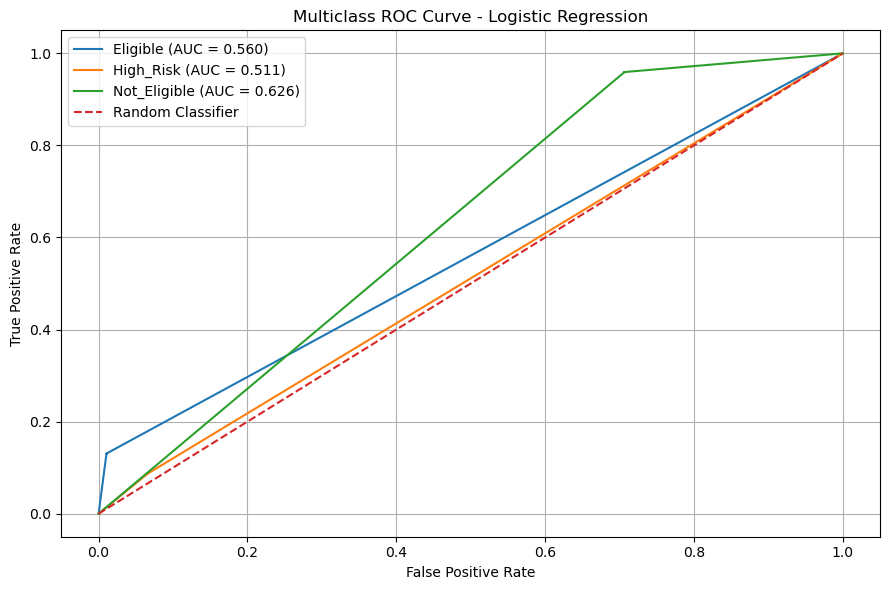

In [145]:
# ============================================================
# STEP 79: MULTICLASS ROC CURVE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ------------------------------------------------------------
# Convert test data using the saved preprocessor
# ------------------------------------------------------------

X_test_transformed = preprocessor_loaded.transform(X_test)

# ------------------------------------------------------------
# Convert actual target values into binary format
# ------------------------------------------------------------

classes = model.classes_

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

# ------------------------------------------------------------
# Get prediction probabilities
# ------------------------------------------------------------

y_probability = model.predict_proba(
    X_test_transformed
)

# ------------------------------------------------------------
# Create ROC curves
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

for i, class_name in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        y_probability[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

# ------------------------------------------------------------
# Random classifier reference line
# ------------------------------------------------------------

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Multiclass ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Step 80 — Final Project Conclusion

# Final Conclusion

The EMI Eligibility Prediction project was developed to predict whether a customer is Eligible, High_Risk, or Not_Eligible for EMI based on financial, employment, demographic, and loan-related factors.

The dataset contained 404,800 records and 27 variables. Data preprocessing included data type conversion, missing-value imputation, duplicate checking, handling unusual credit-score values, categorical encoding, and numerical feature scaling.

Exploratory Data Analysis showed that factors such as monthly salary, existing loans, credit score, bank balance, emergency fund, requested loan amount, and maximum monthly EMI were associated with EMI eligibility.

Three machine learning models were evaluated: Logistic Regression, Random Forest, and Balanced Random Forest. Logistic Regression achieved an accuracy of 78.67% and a High_Risk recall of 65.48%. Random Forest achieved 91.65% accuracy, while Balanced Random Forest achieved the highest accuracy of 91.73%. However, both Random Forest models had very low High_Risk recall of 1.34%.

Therefore, model selection should not be based on accuracy alone. Logistic Regression showed substantially better performance in identifying the High_Risk class, which is important for risk-sensitive EMI decision-making.

The Logistic Regression model achieved a multiclass ROC-AUC score of 0.9237. The final model and preprocessing pipeline were saved for future predictions.

Overall, the project demonstrates how machine learning can be used to support automated EMI eligibility assessment while highlighting the importance of evaluating class imbalance and class-specific performance.